### Evaluating by using `Ragas`

We evaluate 3 aspects of the RAG system:
- **Retrieval**: Quality of context retrieved from the knowledge base
- **Generator**: Quality of the generated answer
- **Hallucination**: Whether the answer stays faithful to the retrieved context

#### Retrieval Metrics

- **Context Relevance**: Measures how relevant the retrieved context is to the user query.
- **Context Precision**: Measures the proportion of retrieved contexts that are relevant to the query. It evaluates whether unnecessary or off-topic documents were included in the retrieval results.

#### Answer Generation Metrics

- **Answer Relevance**: Measures how well the generated answer addresses the user query. It assesses whether the response is directly applicable and addresses the core question.
- **Answer Correctness**: Measures the factual accuracy of the generated answer against ground truth or reference answers. It evaluates whether the information provided is correct.

#### Hallucination Detection

- **Faithfulness**: Measures whether the generated answer is grounded in the retrieved context. A high faithfulness score indicates the answer does not make claims beyond what is stated in the retrieved documents (avoids hallucinations).

In [1]:
!pip install -q ragas
!pip install -q openai


[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from ragas.metrics.collections import *
import ragas.metrics.collections as metrics

print(dir(metrics))

['AgentGoalAccuracy', 'AgentGoalAccuracyWithReference', 'AgentGoalAccuracyWithoutReference', 'AnswerAccuracy', 'AnswerCorrectness', 'AnswerRelevancy', 'BaseMetric', 'BleuScore', 'CHRFScore', 'ContextEntityRecall', 'ContextPrecision', 'ContextPrecisionWithReference', 'ContextPrecisionWithoutReference', 'ContextRecall', 'ContextRelevance', 'ContextUtilization', 'DataCompyScore', 'DistanceMeasure', 'DomainSpecificRubrics', 'ExactMatch', 'FactualCorrectness', 'Faithfulness', 'InstanceSpecificRubrics', 'MultiModalFaithfulness', 'MultiModalRelevance', 'NoiseSensitivity', 'NonLLMStringSimilarity', 'QuotedSpansAlignment', 'ResponseGroundedness', 'RougeScore', 'RubricsScoreWithReference', 'RubricsScoreWithoutReference', 'SQLSemanticEquivalence', 'SemanticSimilarity', 'StringPresence', 'SummaryScore', 'ToolCallAccuracy', 'ToolCallF1', 'TopicAdherence', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_bleu_score', '

In [3]:
import pandas as pd
from ragas import EvaluationDataset, evaluate
from ragas.metrics import (
    AnswerRelevancy,
    AnswerCorrectness,
    ContextPrecision,
    ContextRelevance,
    Faithfulness,
    AnswerAccuracy,
)
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from openai import OpenAI
from ragas.llms import llm_factory
from ragas.embeddings import embedding_factory
import json
import random
import time
random.seed(42)

def build_evaluation_dataset(df, batch_size=5):
    batches = []
    
    for batch_start in range(0, len(df), batch_size):
        batch_end = min(batch_start + batch_size, len(df))
        batch_df = df.iloc[batch_start:batch_end]
        
        dataset = []
        for _, row in batch_df.iterrows():
            context = json.loads(row["context"])
            dataset.append({
                "user_input": row["question"],
                "retrieved_contexts": context,
                "response": row["generated_answer"],
                "reference": row["ground_truth_answer"]
            })
        
        batches.append(EvaluationDataset.from_list(dataset))
    
    return batches

def evaluate_rag(evaluation_dataset, llm, metrics, delay=1):
    """Đánh giá dataset với delay giữa các metrics."""
    result = evaluate(
        dataset=evaluation_dataset,
        metrics=metrics,
        llm=llm,
        show_progress=False,
    )
    time.sleep(delay)  # Chờ sau mỗi evaluation
    return result

def evaluate_and_save_to_df(df, llm, metrics, batch_size=1):
    """
    Evaluate dataframe với batch_size = 1 và lưu scores vào dataframe
    Returns: dataframe gốc + các cột metrics (answer_accuracy, answer_relevancy, etc.)
    
    In ra score trung bình cứ mỗi 20 items
    """
    # Tạo batches
    batches = build_evaluation_dataset(df, batch_size=batch_size)
    
    total_questions = len(df)
    
    # Evaluate và collect results
    all_scores = []
    processed_count = 0  # Đếm tổng số items đã process
    
    for i, batch_dataset in enumerate(batches):
        result = evaluate_rag(evaluation_dataset=batch_dataset, llm=llm, metrics=metrics)
        
        # Convert result (EvaluationDataset) to dictionary of metric scores
        # ragas returns a dataset with .scores attribute
        if hasattr(result, 'scores'):
            scores_dict = result.scores
        else:
            # Fallback: convert to pandas and extract
            scores_dict = result.to_pandas().to_dict('records')
        
        batch_scores = scores_dict if isinstance(scores_dict, list) else [scores_dict]
        all_scores.extend(batch_scores)
        
        # Cập nhật số items đã process
        processed_count += len(batch_scores)
        
        # Cứ mỗi 20 items, in ra average score từ đầu
        if processed_count % 10 == 0:
            scores_df_temp = pd.DataFrame(all_scores)
            avg_scores = scores_df_temp.mean()
            
            score_texts = ""
            for metric, score in avg_scores.items():
                score_texts += f"{metric} : {score:.4f} | "
            print(f"\n AVG Scores | {processed_count}/{total_questions} | {score_texts}")
            print()
    
    # Create scores dataframe
    scores_df = pd.DataFrame(all_scores)
    
    # Reset index để merge dễ hơn
    df_reset = df.reset_index(drop=True)
    
    # Merge scores với original dataframe
    result_df = pd.concat([df_reset, scores_df], axis=1)
    
    return result_df


/tmp/ipykernel_1594919/2865989136.py:3: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import (
/tmp/ipykernel_1594919/2865989136.py:3: DeprecationWarning: Importing AnswerCorrectness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerCorrectness
  from ragas.metrics import (
/tmp/ipykernel_1594919/2865989136.py:3: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import (
/tmp/ipykernel_1594919/2865989136.py:3: DeprecationWarning: Importing ContextRelevance from 'ragas.metrics' is deprecated

In [ ]:
from dataclasses import dataclass
from typing import List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from config import settings, LLM_ONLY_MODEL

model_name =  LLM_ONLY_MODEL["model_name"]

df_diemchuan = pd.read_csv("output/ablation_diemchuan_02.csv")
df_tuyensinh = pd.read_csv("output/ablation_tuyensinh_02.csv")

In [5]:
df_diemchuan["pipeline"].unique()

array(['ablation_no_text2sql'], dtype=object)

In [6]:
df_tuyensinh["pipeline"].unique()

array(['ablation_no_text2sql'], dtype=object)

In [ ]:
df_ablation_no_text2sql_tuyensinh = df_tuyensinh[df_tuyensinh["pipeline"] == "ablation_no_text2sql"]
df_ablation_no_text2sql_diemchuan = df_diemchuan[df_diemchuan["pipeline"] == "ablation_no_text2sql"]


print(f"df_ablation_no_text2sql_tuyensinh: {len(df_ablation_no_text2sql_tuyensinh)} questions")
print(f"df_ablation_no_text2sql_diemchuan: {len(df_ablation_no_text2sql_diemchuan)} questions")


df_ablation_no_text2sql_tuyensinh: 400 questions
df_ablation_no_text2sql_diemchuan: 200 questions


In [ ]:
# df_tuyensinh_llm_only = df_tuyensinh[df_tuyensinh["pipeline"] == "llm_only"]
# df_tuyensinh_our_rag = df_tuyensinh[df_tuyensinh["pipeline"] == "our_rag"]
# df_tuyensinh_basic_rag = df_tuyensinh[df_tuyensinh["pipeline"] == "basic_rag"]

# print(f"df_llm_only: {len(df_tuyensinh_llm_only)} questions")
# print(f"df_our_rag: {len(df_tuyensinh_our_rag)} questions")
# print(f"df_basic_rag: {len(df_tuyensinh_basic_rag)} questions")

df_llm_only: 400 questions
df_our_rag: 400 questions
df_basic_rag: 400 questions


In [ ]:
# df_tuyensinh_our_rag.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 800 to 1199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   qid                     400 non-null    int64  
 1   pipeline                400 non-null    object 
 2   question                400 non-null    object 
 3   ground_truth_answer     400 non-null    object 
 4   generated_answer        400 non-null    object 
 5   context                 400 non-null    object 
 6   retrieved_doc_contents  400 non-null    object 
 7   tool_used               400 non-null    object 
 8   latency_s               400 non-null    float64
 9   latency_cached_s        400 non-null    float64
dtypes: float64(2), int64(1), object(7)
memory usage: 34.4+ KB


In [ ]:
# df_diemchuan_llm_only = df_diemchuan[df_diemchuan["pipeline"] == "llm_only"]
# df_diemchuan_our_rag = df_diemchuan[df_diemchuan["pipeline"] == "our_rag"]
# df_diemchuan_basic_rag = df_diemchuan[df_diemchuan["pipeline"] == "basic_rag"]

# print(f"df_llm_only: {len(df_diemchuan_llm_only)} questions")
# print(f"df_our_rag: {len(df_diemchuan_our_rag)} questions")
# print(f"df_basic_rag: {len(df_diemchuan_basic_rag)} questions")

df_llm_only: 200 questions
df_our_rag: 200 questions
df_basic_rag: 200 questions


In [ ]:
# import os

# # Create output directories
# os.makedirs("evaluated_output/our_rag", exist_ok=True)
# os.makedirs("evaluated_output/llm_only", exist_ok=True)
# os.makedirs("evaluated_output/basic_rag", exist_ok=True)

In [22]:
import os
os.makedirs("evaluated_output/ablation_no_text2sql", exist_ok=True)

### 2. Đánh giá `llm_only`, `basic_rag`, `our_rag`

In [ ]:
# openai_client = OpenAI(api_key=settings.api_key)
# llm = ChatOpenAI(
#     model_name="gpt-4o-mini",
#     api_key=settings.api_key,
#     temperature=0
# )

# metrics = [AnswerAccuracy(), AnswerRelevancy()]

#### 2.1 Our_rag

In [ ]:
# # Evaluate với batch_size=1 và lưu scores vào dataframe
# print("=== Evaluating our_rag_text ===")
# df_tuyensinh_our_rag_with_scores = evaluate_and_save_to_df(
#     df_tuyensinh_our_rag, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )

# print("=== Evaluating our_rag_text2sql ===")
# df_diemchuan_our_rag_with_scores = evaluate_and_save_to_df(
#     df_diemchuan_our_rag, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )


=== Evaluating our_rag_text ===

 AVG Scores | 10/400 | nv_accuracy : 0.6750 | answer_relevancy : 0.7213 | 


 AVG Scores | 20/400 | nv_accuracy : 0.6500 | answer_relevancy : 0.7479 | 


 AVG Scores | 30/400 | nv_accuracy : 0.5917 | answer_relevancy : 0.6876 | 


 AVG Scores | 40/400 | nv_accuracy : 0.5750 | answer_relevancy : 0.6706 | 


 AVG Scores | 50/400 | nv_accuracy : 0.5400 | answer_relevancy : 0.6503 | 


 AVG Scores | 60/400 | nv_accuracy : 0.5833 | answer_relevancy : 0.6744 | 


 AVG Scores | 70/400 | nv_accuracy : 0.5821 | answer_relevancy : 0.6555 | 


 AVG Scores | 80/400 | nv_accuracy : 0.6156 | answer_relevancy : 0.6617 | 


 AVG Scores | 90/400 | nv_accuracy : 0.6417 | answer_relevancy : 0.6690 | 


 AVG Scores | 100/400 | nv_accuracy : 0.6150 | answer_relevancy : 0.6853 | 


 AVG Scores | 110/400 | nv_accuracy : 0.6205 | answer_relevancy : 0.6884 | 


 AVG Scores | 120/400 | nv_accuracy : 0.6271 | answer_relevancy : 0.6987 | 


 AVG Scores | 130/400 | nv_accuracy : 0.

In [ ]:
# import numpy as np 

# # Get metric columns (exclude the original columns)
# metric_cols = [col for col in df_tuyensinh_our_rag_with_scores.columns 
#                if col not in df_tuyensinh_our_rag.columns]

# # Calculate average scores for our_rag
# avg_results_our_rag_text = {col: df_tuyensinh_our_rag_with_scores[col].mean() for col in metric_cols}
# avg_results_our_rag_text2sql = {col: df_diemchuan_our_rag_with_scores[col].mean() for col in metric_cols}

# print(f"avg_results_our_rag_text: {avg_results_our_rag_text}")
# print(f"avg_results_our_rag_text2sql: {avg_results_our_rag_text2sql}")


avg_results_our_rag_text: {'nv_accuracy': np.float64(0.535), 'answer_relevancy': np.float64(0.6420149942601645)}
avg_results_our_rag_text2sql: {'nv_accuracy': np.float64(0.8875), 'answer_relevancy': np.float64(0.7651143775501934)}


In [ ]:
# # Save answer metrics (batch_size=1)
# df_tuyensinh_our_rag_with_scores.to_csv("evaluated_output/our_rag/tuyensinh_answer.csv", index=False)
# df_diemchuan_our_rag_with_scores.to_csv("evaluated_output/our_rag/diemchuan_answer.csv", index=False)

#### 2.2 llm_only

In [ ]:
# # Evaluate với batch_size=1 và lưu scores vào dataframe
# print("=== Evaluating llm_only_text ===")
# df_tuyensinh_llm_only_with_scores = evaluate_and_save_to_df(
#     df_tuyensinh_llm_only, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )

# print("=== Evaluating llm_only_text2sql ===")
# df_diemchuan_llm_only_with_scores = evaluate_and_save_to_df(
#     df_diemchuan_llm_only, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )

=== Evaluating llm_only_text ===

 AVG Scores | 10/400 | nv_accuracy : 0.2500 | answer_relevancy : 0.2539 | 


 AVG Scores | 20/400 | nv_accuracy : 0.3875 | answer_relevancy : 0.5142 | 


 AVG Scores | 30/400 | nv_accuracy : 0.3417 | answer_relevancy : 0.4008 | 


 AVG Scores | 40/400 | nv_accuracy : 0.3625 | answer_relevancy : 0.4409 | 


 AVG Scores | 50/400 | nv_accuracy : 0.3600 | answer_relevancy : 0.4484 | 


 AVG Scores | 60/400 | nv_accuracy : 0.3458 | answer_relevancy : 0.4291 | 


 AVG Scores | 70/400 | nv_accuracy : 0.3500 | answer_relevancy : 0.4024 | 


 AVG Scores | 80/400 | nv_accuracy : 0.3375 | answer_relevancy : 0.3623 | 


 AVG Scores | 90/400 | nv_accuracy : 0.3361 | answer_relevancy : 0.3573 | 


 AVG Scores | 100/400 | nv_accuracy : 0.3225 | answer_relevancy : 0.3379 | 


 AVG Scores | 110/400 | nv_accuracy : 0.3091 | answer_relevancy : 0.3148 | 


 AVG Scores | 120/400 | nv_accuracy : 0.2917 | answer_relevancy : 0.2886 | 


 AVG Scores | 130/400 | nv_accuracy : 0

In [ ]:
# import numpy as np 

# # Get metric columns
# metric_cols = [col for col in df_tuyensinh_llm_only_with_scores.columns 
#                if col not in df_tuyensinh_llm_only.columns]

# # Calculate average scores for llm_only
# avg_results_llm_only_text = {col: df_tuyensinh_llm_only_with_scores[col].mean() for col in metric_cols}
# avg_results_llm_only_text2sql = {col: df_diemchuan_llm_only_with_scores[col].mean() for col in metric_cols}

# print(f"avg_results_llm_only_text: {avg_results_llm_only_text}")
# print(f"avg_results_llm_only_text2sql: {avg_results_llm_only_text2sql}")


avg_results_llm_only_text: {'nv_accuracy': np.float64(0.23625), 'answer_relevancy': np.float64(0.24318768546315403)}
avg_results_llm_only_text2sql: {'nv_accuracy': np.float64(0.0), 'answer_relevancy': np.float64(0.0)}


In [ ]:
# df_tuyensinh_llm_only_with_scores.to_csv("evaluated_output/llm_only/tuyensinh_answer.csv", index=False)
# df_diemchuan_llm_only_with_scores.to_csv("evaluated_output/llm_only/diemchuan_answer.csv", index=False)

#### 2.3 basic_rag

In [ ]:
# # Evaluate với batch_size=1 và lưu scores vào dataframe
# print("=== Evaluating basic_rag_text ===")
# df_tuyensinh_basic_rag_with_scores = evaluate_and_save_to_df(
#     df_tuyensinh_basic_rag, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )

# print("=== Evaluating basic_rag_text2sql ===")
# df_diemchuan_basic_rag_with_scores = evaluate_and_save_to_df(
#     df_diemchuan_basic_rag, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )


=== Evaluating basic_rag_text ===

 AVG Scores | 10/400 | nv_accuracy : 0.5750 | answer_relevancy : 0.6462 | 


 AVG Scores | 20/400 | nv_accuracy : 0.5000 | answer_relevancy : 0.6554 | 


 AVG Scores | 30/400 | nv_accuracy : 0.5917 | answer_relevancy : 0.6511 | 


 AVG Scores | 40/400 | nv_accuracy : 0.5875 | answer_relevancy : 0.6638 | 


 AVG Scores | 50/400 | nv_accuracy : 0.5500 | answer_relevancy : 0.6626 | 


 AVG Scores | 60/400 | nv_accuracy : 0.5792 | answer_relevancy : 0.6854 | 


 AVG Scores | 70/400 | nv_accuracy : 0.5500 | answer_relevancy : 0.6675 | 


 AVG Scores | 80/400 | nv_accuracy : 0.5687 | answer_relevancy : 0.6664 | 


 AVG Scores | 90/400 | nv_accuracy : 0.5861 | answer_relevancy : 0.6656 | 


 AVG Scores | 100/400 | nv_accuracy : 0.5700 | answer_relevancy : 0.6628 | 


 AVG Scores | 110/400 | nv_accuracy : 0.5795 | answer_relevancy : 0.6739 | 


 AVG Scores | 120/400 | nv_accuracy : 0.5833 | answer_relevancy : 0.6764 | 


 AVG Scores | 130/400 | nv_accuracy : 

In [ ]:
# import numpy as np 

# # Get metric columns
# metric_cols = [col for col in df_tuyensinh_basic_rag_with_scores.columns 
#                if col not in df_tuyensinh_basic_rag.columns]

# # Calculate average scores for basic_rag
# avg_results_basic_rag_text = {col: df_tuyensinh_basic_rag_with_scores[col].mean() for col in metric_cols}
# avg_results_basic_rag_text2sql = {col: df_diemchuan_basic_rag_with_scores[col].mean() for col in metric_cols}

# print(f"avg_results_basic_rag_text: {avg_results_basic_rag_text}")
# print(f"avg_results_basic_rag_text2sql: {avg_results_basic_rag_text2sql}")


avg_results_basic_rag_text: {'nv_accuracy': np.float64(0.500625), 'answer_relevancy': np.float64(0.6063675367074554)}
avg_results_basic_rag_text2sql: {'nv_accuracy': np.float64(0.36125), 'answer_relevancy': np.float64(0.3387674325857475)}


In [ ]:
# df_tuyensinh_basic_rag_with_scores.to_csv("evaluated_output/basic_rag/tuyensinh_answer.csv", index=False)
# df_diemchuan_basic_rag_with_scores.to_csv("evaluated_output/basic_rag/diemchuan_answer.csv", index=False)


### Đánh giá context
- Chỉ đánh giá trên tập text, không đánh giá sql

In [ ]:
# metrics = [ContextPrecision(), ContextRelevance()] 

In [ ]:
# # Evaluate context metrics với batch_size=1 và lưu scores vào dataframe
# print("=== Evaluating our_rag_text context ===")
# df_tuyensinh_our_rag_context_with_scores = evaluate_and_save_to_df(
#     df_tuyensinh_our_rag, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )

=== Evaluating our_rag_text context ===

 AVG Scores | 10/400 | context_precision : 0.7950 | nv_context_relevance : 0.9000 | 


 AVG Scores | 20/400 | context_precision : 0.7592 | nv_context_relevance : 0.8625 | 


 AVG Scores | 30/400 | context_precision : 0.7433 | nv_context_relevance : 0.8333 | 


 AVG Scores | 40/400 | context_precision : 0.7591 | nv_context_relevance : 0.8688 | 


 AVG Scores | 50/400 | context_precision : 0.6763 | nv_context_relevance : 0.8700 | 


 AVG Scores | 60/400 | context_precision : 0.7146 | nv_context_relevance : 0.8917 | 


 AVG Scores | 70/400 | context_precision : 0.7182 | nv_context_relevance : 0.8786 | 


 AVG Scores | 80/400 | context_precision : 0.7366 | nv_context_relevance : 0.8812 | 


 AVG Scores | 90/400 | context_precision : 0.7573 | nv_context_relevance : 0.8917 | 


 AVG Scores | 100/400 | context_precision : 0.7406 | nv_context_relevance : 0.8975 | 


 AVG Scores | 110/400 | context_precision : 0.7567 | nv_context_relevance : 0.9068 | 




In [ ]:
# # Save context metrics (only for text datasets)
# df_tuyensinh_our_rag_context_with_scores.to_csv("evaluated_output/our_rag/tuyensinh_context.csv", index=False)

In [ ]:
# # Evaluate context metrics với batch_size=1 và lưu scores vào dataframe
# print("=== Evaluating basic_rag_text context ===")
# df_tuyensinh_basic_rag_context_with_scores = evaluate_and_save_to_df(
#     df_tuyensinh_basic_rag, 
#     llm=llm, 
#     metrics=metrics,
#     batch_size=1
# )

=== Evaluating basic_rag_text context ===



 AVG Scores | 10/400 | context_precision : 0.6350 | nv_context_relevance : 0.8000 | 


 AVG Scores | 20/400 | context_precision : 0.6775 | nv_context_relevance : 0.8500 | 


 AVG Scores | 30/400 | context_precision : 0.6959 | nv_context_relevance : 0.8667 | 


 AVG Scores | 40/400 | context_precision : 0.6835 | nv_context_relevance : 0.8750 | 


 AVG Scores | 50/400 | context_precision : 0.6184 | nv_context_relevance : 0.8750 | 


 AVG Scores | 60/400 | context_precision : 0.6408 | nv_context_relevance : 0.8917 | 


 AVG Scores | 70/400 | context_precision : 0.6258 | nv_context_relevance : 0.8607 | 


 AVG Scores | 80/400 | context_precision : 0.6255 | nv_context_relevance : 0.8531 | 


 AVG Scores | 90/400 | context_precision : 0.6324 | nv_context_relevance : 0.8583 | 


 AVG Scores | 100/400 | context_precision : 0.6350 | nv_context_relevance : 0.8600 | 


 AVG Scores | 110/400 | context_precision : 0.6463 | nv_context_relevance : 0.8727 | 


 AVG Scores | 120/400 | context_precisio

In [ ]:
# df_tuyensinh_basic_rag_context_with_scores.to_csv("evaluated_output/basic_rag/tuyensinh_context.csv", index=False)

In [ ]:
# import numpy as np 

# # Get metric columns for context evaluation
# metric_cols_context_our = [col for col in df_tuyensinh_our_rag_context_with_scores.columns 
#                            if col not in df_tuyensinh_our_rag.columns]
# metric_cols_context_basic = [col for col in df_tuyensinh_basic_rag_context_with_scores.columns 
#                              if col not in df_tuyensinh_basic_rag.columns]

# # Calculate average scores for context evaluation
# avg_results_our_rag_context = {col: df_tuyensinh_our_rag_context_with_scores[col].mean() for col in metric_cols_context_our}
# avg_results_basic_rag_context = {col: df_tuyensinh_basic_rag_context_with_scores[col].mean() for col in metric_cols_context_basic}

# print(f"avg_results_our_rag_context: {avg_results_our_rag_context}")
# print(f"avg_results_basic_rag_context: {avg_results_basic_rag_context}")


avg_results_our_rag_context: {'context_precision': np.float64(0.7620694444017428), 'nv_context_relevance': np.float64(0.83625)}
avg_results_basic_rag_context: {'context_precision': np.float64(0.5830402124012056), 'nv_context_relevance': np.float64(0.82875)}


## Calculate Confidence Intervals

In [16]:
import numpy as np
# Bootstrap function for confidence intervals
def calculate_bootstrap_ci(data, metric_col, bootstrap_indices=None, n_bootstrap=5000, ci=95):
    n = len(data)
    metric_values = data[metric_col].values
    
    # Generate bootstrap indices if not provided
    if bootstrap_indices is None:
        bootstrap_indices = []
        for _ in range(n_bootstrap):
            bootstrap_indices.append(np.random.choice(np.arange(n), size=n, replace=True))
    
    # Calculate bootstrap means using the provided indices
    bootstrap_means = []
    for indices in bootstrap_indices:
        bootstrap_means.append(metric_values[indices].mean())
    
    mean = metric_values.mean()
    lower_percentile = (100 - ci) / 2
    upper_percentile = 100 - lower_percentile
    
    lower = np.percentile(bootstrap_means, lower_percentile)
    upper = np.percentile(bootstrap_means, upper_percentile)
    
    return {
        'mean': mean,
        'lower': lower,
        'upper': upper,
        'bootstrap_means': bootstrap_means
    }

# Helper function to generate bootstrap indices once for all metrics
def generate_bootstrap_indices(n_samples, n_bootstrap=5000):
    """Generate bootstrap indices once to use across all metrics."""
    indices = []
    for _ in range(n_bootstrap):
        indices.append(np.random.choice(np.arange(n_samples), size=n_samples, replace=True))
    return indices

### Retrieval metrics

In [ ]:
# import pandas as pd
# import numpy as np

# context_models = ['basic_rag', 'our_rag']
# context_metrics = ['context_precision', 'nv_context_relevance']

# # Load context data
# context_data = {}
# for model in context_models:
#     path = f"evaluated_output/{model}/tuyensinh_context.csv"
#     df = pd.read_csv(path)
#     context_data[model] = df[['qid'] + context_metrics]
#     print(f"{model} context data loaded: {len(df)} rows")


basic_rag context data loaded: 400 rows
our_rag context data loaded: 400 rows


In [ ]:
# # Generate bootstrap indices ONCE for all context models
# # (all models should have same sample size)
# n = len(context_data[context_models[0]])
# context_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
# print(f"Generated {len(context_bootstrap_indices)} bootstrap indices for context metrics comparison\n")

# # Calculate context metric CIs using SAME bootstrap indices for all models
# context_cis = {}
# for model in context_models:
#     context_cis[model] = {}
    
#     # Apply same indices to all metrics and all models
#     for metric in context_metrics:
#         ci = calculate_bootstrap_ci(context_data[model], metric, bootstrap_indices=context_bootstrap_indices)
#         context_cis[model][metric] = ci
#         print(f"\n{model} - {metric}:")
#         print(f"  Mean: {ci['mean']:.4f}")
#         print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for context metrics comparison


basic_rag - context_precision:
  Mean: 0.5830
  95% CI: [0.5489, 0.6165]

basic_rag - nv_context_relevance:
  Mean: 0.8287
  95% CI: [0.7937, 0.8625]

our_rag - context_precision:
  Mean: 0.7621
  95% CI: [0.7285, 0.7955]

our_rag - nv_context_relevance:
  Mean: 0.8363
  95% CI: [0.8019, 0.8681]


### Answer metrics

In [ ]:
# answer_models = ['basic_rag', 'llm_only', 'our_rag']
# answer_metrics = ['nv_accuracy', 'answer_relevancy']

# # Load and concatenate answer data
# answer_data = {}
# for model in answer_models:
#     # Load both tuyensinh and diemchuan answer data
#     df_tuyensinh = pd.read_csv(f"evaluated_output/{model}/tuyensinh_answer.csv")
#     df_diemchuan = pd.read_csv(f"evaluated_output/{model}/diemchuan_answer.csv")
    
#     # Extract relevant columns
#     df_tuyensinh_subset = df_tuyensinh[['qid'] + answer_metrics]
#     df_diemchuan_subset = df_diemchuan[['qid'] + answer_metrics]
    
#     # Concatenate both dataframes
#     answer_data[model] = pd.concat([df_tuyensinh_subset, df_diemchuan_subset], ignore_index=True)
    
#     print(f"{model} answer data loaded:")
#     print(f"  - tuyensinh: {len(df_tuyensinh_subset)} rows")
#     print(f"  - diemchuan: {len(df_diemchuan_subset)} rows")
#     print(f"  - total: {len(answer_data[model])} rows")

# # Generate bootstrap indices ONCE for all answer models
# # (all models should have same sample size)
# n = len(answer_data[answer_models[0]])
# answer_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
# print(f"\nGenerated {len(answer_bootstrap_indices)} bootstrap indices for answer metrics comparison")

# # Calculate answer metric CIs using SAME bootstrap indices for all models
# answer_cis = {}
# for model in answer_models:
#     answer_cis[model] = {}
    
#     # Apply same indices to all metrics and all models
#     for metric in answer_metrics:
#         ci = calculate_bootstrap_ci(answer_data[model], metric, bootstrap_indices=answer_bootstrap_indices)
#         answer_cis[model][metric] = ci
#         print(f"\n{model} - {metric}:")
#         print(f"  Mean: {ci['mean']:.4f}")
#         print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


basic_rag answer data loaded:
  - tuyensinh: 400 rows
  - diemchuan: 200 rows
  - total: 600 rows
llm_only answer data loaded:
  - tuyensinh: 400 rows
  - diemchuan: 200 rows
  - total: 600 rows
our_rag answer data loaded:
  - tuyensinh: 400 rows
  - diemchuan: 200 rows
  - total: 600 rows

Generated 5000 bootstrap indices for answer metrics comparison

basic_rag - nv_accuracy:
  Mean: 0.4542
  95% CI: [0.4225, 0.4871]

basic_rag - answer_relevancy:
  Mean: 0.5172
  95% CI: [0.4877, 0.5472]

llm_only - nv_accuracy:
  Mean: 0.1575
  95% CI: [0.1392, 0.1767]

llm_only - answer_relevancy:
  Mean: 0.1621
  95% CI: [0.1373, 0.1890]

our_rag - nv_accuracy:
  Mean: 0.6525
  95% CI: [0.6217, 0.6829]

our_rag - answer_relevancy:
  Mean: 0.6830
  95% CI: [0.6595, 0.7054]


In [ ]:
# # Summary Table for Context Metrics
# print("\n" + "="*80)
# print("CONTEXT METRICS SUMMARY (95% Confidence Intervals)")
# print("="*80)
# for model in context_models:
#     print(f"\n{model.upper()}:")
#     for metric in context_metrics:
#         ci = context_cis[model][metric]
#         print(f"  {metric:25s}: {ci['mean']:.4f} [{ci['lower']:.4f}, {ci['upper']:.4f}]")

# # Summary Table for Answer Metrics
# print("\n" + "="*80)
# print("ANSWER METRICS SUMMARY (95% Confidence Intervals)")
# print("="*80)
# for model in answer_models:
#     print(f"\n{model.upper()}:")
#     for metric in answer_metrics:
#         ci = answer_cis[model][metric]
#         print(f"  {metric:25s}: {ci['mean']:.4f} [{ci['lower']:.4f}, {ci['upper']:.4f}]")



CONTEXT METRICS SUMMARY (95% Confidence Intervals)

BASIC_RAG:
  context_precision        : 0.5830 [0.5489, 0.6165]
  nv_context_relevance     : 0.8287 [0.7937, 0.8625]

OUR_RAG:
  context_precision        : 0.7621 [0.7285, 0.7955]
  nv_context_relevance     : 0.8363 [0.8019, 0.8681]

ANSWER METRICS SUMMARY (95% Confidence Intervals)

BASIC_RAG:
  nv_accuracy              : 0.4542 [0.4225, 0.4871]
  answer_relevancy         : 0.5172 [0.4877, 0.5472]

LLM_ONLY:
  nv_accuracy              : 0.1575 [0.1392, 0.1767]
  answer_relevancy         : 0.1621 [0.1373, 0.1890]

OUR_RAG:
  nv_accuracy              : 0.6525 [0.6217, 0.6829]
  answer_relevancy         : 0.6830 [0.6595, 0.7054]


### 2.6 Đánh giá latency

In [4]:
import pandas as pd
evaluated_diemchuan = pd.read_csv("output/evaluation_results_diemchuan.csv")


In [5]:
evaluated_tuyensinh = pd.read_csv("output/evaluation_results_tuyensinh.csv")


In [6]:
# Check available columns
print("Columns in evaluated_diemchuan:")
print(evaluated_diemchuan.columns.tolist())
print("\nColumns in evaluated_tuyensinh:")
print(evaluated_tuyensinh.columns.tolist())
print("\nShape - diemchuan:", evaluated_diemchuan.shape, "tuyensinh:", evaluated_tuyensinh.shape)

Columns in evaluated_diemchuan:
['qid', 'pipeline', 'question', 'ground_truth_answer', 'generated_answer', 'context', 'retrieved_doc_contents', 'tool_used', 'latency_s', 'latency_cached_s']

Columns in evaluated_tuyensinh:
['qid', 'pipeline', 'question', 'ground_truth_answer', 'generated_answer', 'context', 'retrieved_doc_contents', 'tool_used', 'latency_s', 'latency_cached_s']

Shape - diemchuan: (600, 10) tuyensinh: (1200, 10)


In [10]:
# Bootstrap analysis for latency metrics by pipeline
import numpy as np
from scipy import stats
import pandas as pd

def bootstrap_ci(data, n_bootstrap=10000, ci=95):
    """
    Calculate bootstrap confidence interval for mean
    
    Args:
        data: array-like of values
        n_bootstrap: number of bootstrap samples
        ci: confidence interval (default 95)
    
    Returns:
        dict with mean, lower_ci, upper_ci
    """
    # Remove NaN values
    data = np.array(data)
    data = data[~np.isnan(data)]
    
    # Original mean
    mean = np.mean(data)
    
    # Bootstrap resampling
    bootstrap_means = []
    np.random.seed(42)
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))
    
    bootstrap_means = np.array(bootstrap_means)
    
    # Calculate confidence intervals
    alpha = (100 - ci) / 2
    lower_ci = np.percentile(bootstrap_means, alpha)
    upper_ci = np.percentile(bootstrap_means, 100 - alpha)
    
    return {
        'mean': mean,
        'lower_ci': lower_ci,
        'upper_ci': upper_ci,
        'std': np.std(bootstrap_means)
    }

# Combine both datasets for comprehensive analysis
combined_df = pd.concat([evaluated_diemchuan, evaluated_tuyensinh], ignore_index=True)

# Get unique pipelines
pipelines = sorted(combined_df['pipeline'].unique())
print(f"Pipelines: {pipelines}\n")

# Bootstrap analysis by pipeline
results = []

for pipeline in pipelines:
    pipeline_data = combined_df[combined_df['pipeline'] == pipeline]
    
    # Bootstrap analysis for latency_s
    latency_s_ci = bootstrap_ci(pipeline_data['latency_s'].values, n_bootstrap=5000)
    
    # Bootstrap analysis for latency_cached_s
    latency_cached_ci = bootstrap_ci(pipeline_data['latency_cached_s'].values, n_bootstrap=5000)
    
    results.append({
        'Pipeline': pipeline,
        'N': len(pipeline_data),
        'latency_s_mean': latency_s_ci['mean'],
        'latency_s_95ci_lower': latency_s_ci['lower_ci'],
        'latency_s_95ci_upper': latency_s_ci['upper_ci'],
        'latency_s_std': latency_s_ci['std'],
        'latency_cached_s_mean': latency_cached_ci['mean'],
        'latency_cached_s_95ci_lower': latency_cached_ci['lower_ci'],
        'latency_cached_s_95ci_upper': latency_cached_ci['upper_ci'],
        'latency_cached_s_std': latency_cached_ci['std'],
    })

# Create results dataframe
results_df = pd.DataFrame(results)

print("=" * 100)
print("BOOTSTRAP ANALYSIS: LATENCY METRICS BY PIPELINE (95% Confidence Intervals)")
print("=" * 100)
print()

# Display latency_s results
print("LATENCY_S (Full Response Time in seconds):")
print("-" * 100)
for idx, row in results_df.iterrows():
    print(f"{row['Pipeline']:15} | N={row['N']:4} | Mean: {row['latency_s_mean']:.4f}s | 95%CI: [{row['latency_s_95ci_lower']:.4f}, {row['latency_s_95ci_upper']:.4f}]")
print()

# Display latency_cached_s results
print("LATENCY_CACHED_S (Cached Response Time in seconds):")
print("-" * 100)
for idx, row in results_df.iterrows():
    print(f"{row['Pipeline']:15} | N={row['N']:4} | Mean: {row['latency_cached_s_mean']:.4f}s | 95%CI: [{row['latency_cached_s_95ci_lower']:.4f}, {row['latency_cached_s_95ci_upper']:.4f}]")
print()

# Display as formatted dataframe
print("=" * 100)
print("SUMMARY TABLE:")
print("=" * 100)
display_df = results_df.copy()
display_df['latency_s'] = display_df.apply(
    lambda x: f"{x['latency_s_mean']:.4f} [{x['latency_s_95ci_lower']:.4f}, {x['latency_s_95ci_upper']:.4f}]", axis=1
)
display_df['latency_cached_s'] = display_df.apply(
    lambda x: f"{x['latency_cached_s_mean']:.4f} [{x['latency_cached_s_95ci_lower']:.4f}, {x['latency_cached_s_95ci_upper']:.4f}]", axis=1
)
print(display_df[['Pipeline', 'N', 'latency_s', 'latency_cached_s']].to_string(index=False))

Pipelines: ['basic_rag', 'llm_only', 'our_rag']

BOOTSTRAP ANALYSIS: LATENCY METRICS BY PIPELINE (95% Confidence Intervals)

LATENCY_S (Full Response Time in seconds):
----------------------------------------------------------------------------------------------------
basic_rag       | N= 600 | Mean: 6.2103s | 95%CI: [5.8731, 6.5932]
llm_only        | N= 600 | Mean: 19.2055s | 95%CI: [18.8228, 19.6085]
our_rag         | N= 600 | Mean: 22.6153s | 95%CI: [22.0130, 23.2480]

LATENCY_CACHED_S (Cached Response Time in seconds):
----------------------------------------------------------------------------------------------------
basic_rag       | N= 600 | Mean: 0.2888s | 95%CI: [0.2798, 0.2988]
llm_only        | N= 600 | Mean: 0.3209s | 95%CI: [0.3031, 0.3422]
our_rag         | N= 600 | Mean: 0.2914s | 95%CI: [0.2825, 0.3010]

SUMMARY TABLE:
 Pipeline   N                  latency_s        latency_cached_s
basic_rag 600    6.2103 [5.8731, 6.5932] 0.2888 [0.2798, 0.2988]
 llm_only 600 19.2055 [

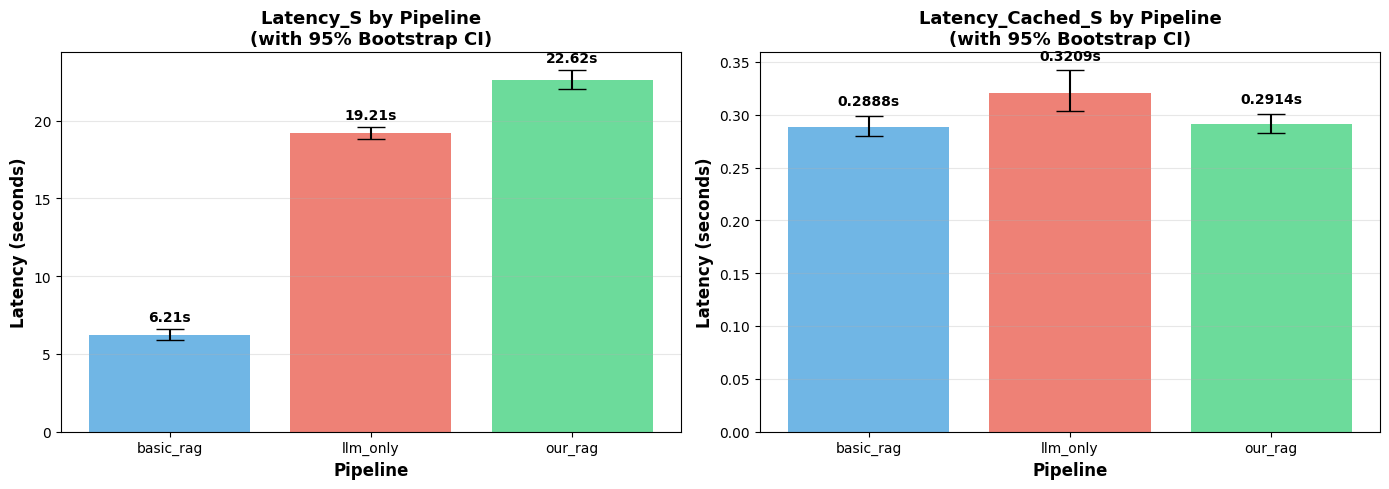


Visualization saved to: output/bootstrap_latency_analysis.png


In [8]:
# Visualize the results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: latency_s with 95% CI
ax = axes[0]
pipelines_list = results_df['Pipeline'].tolist()
x_pos = np.arange(len(pipelines_list))

means = results_df['latency_s_mean'].values
errors_lower = results_df['latency_s_mean'].values - results_df['latency_s_95ci_lower'].values
errors_upper = results_df['latency_s_95ci_upper'].values - results_df['latency_s_mean'].values

ax.bar(x_pos, means, yerr=[errors_lower, errors_upper], capsize=10, alpha=0.7, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_xlabel('Pipeline', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Latency_S by Pipeline\n(with 95% Bootstrap CI)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(pipelines_list)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (mean, err_lower, err_upper) in enumerate(zip(means, errors_lower, errors_upper)):
    ax.text(i, mean + err_upper + 0.5, f'{mean:.2f}s', ha='center', fontsize=10, fontweight='bold')

# Plot 2: latency_cached_s with 95% CI
ax = axes[1]
means_cached = results_df['latency_cached_s_mean'].values
errors_lower_cached = results_df['latency_cached_s_mean'].values - results_df['latency_cached_s_95ci_lower'].values
errors_upper_cached = results_df['latency_cached_s_95ci_upper'].values - results_df['latency_cached_s_mean'].values

ax.bar(x_pos, means_cached, yerr=[errors_lower_cached, errors_upper_cached], capsize=10, alpha=0.7, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_xlabel('Pipeline', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Latency_Cached_S by Pipeline\n(with 95% Bootstrap CI)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(pipelines_list)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (mean, err_lower, err_upper) in enumerate(zip(means_cached, errors_lower_cached, errors_upper_cached)):
    ax.text(i, mean + err_upper + 0.01, f'{mean:.4f}s', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('output/bootstrap_latency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: output/bootstrap_latency_analysis.png")

In [9]:
# Export results to CSV
export_df = results_df.copy()
export_df.columns = [
    'Pipeline', 'N',
    'latency_s_mean', 'latency_s_95ci_lower', 'latency_s_95ci_upper', 'latency_s_bootstrap_std',
    'latency_cached_s_mean', 'latency_cached_s_95ci_lower', 'latency_cached_s_95ci_upper', 'latency_cached_s_bootstrap_std'
]

# Round to 4 decimal places for readability
for col in export_df.columns[2:]:
    export_df[col] = export_df[col].round(4)

export_df.to_csv('output/bootstrap_latency_results.csv', index=False)

print("Results exported to: output/bootstrap_latency_results.csv")
print("\nDetailed Results (CSV format):")
print(export_df.to_string(index=False))

Results exported to: output/bootstrap_latency_results.csv

Detailed Results (CSV format):
 Pipeline   N  latency_s_mean  latency_s_95ci_lower  latency_s_95ci_upper  latency_s_bootstrap_std  latency_cached_s_mean  latency_cached_s_95ci_lower  latency_cached_s_95ci_upper  latency_cached_s_bootstrap_std
basic_rag 600          6.2103                5.8726                6.5963                   0.1843                 0.2888                       0.2797                       0.2988                          0.0049
 llm_only 600         19.2055               18.8157               19.6093                   0.2019                 0.3209                       0.3033                       0.3421                          0.0100
  our_rag 600         22.6153               22.0091               23.2502                   0.3154                 0.2914                       0.2824                       0.3010                          0.0048


### 3. Đánh giá ablation study

#### 3.1 ablation_no_text2sql

In [8]:
openai_client = OpenAI(api_key=settings.api_key)
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    api_key=settings.api_key,
    temperature=0
)

metrics = [AnswerAccuracy(), AnswerRelevancy()]

In [10]:
df_ablation_no_text2sql_tuyensinh.head(5)

,qid,pipeline,question,ground_truth_answer,generated_answer,context,retrieved_doc_contents,tool_used,latency_s,latency_cached_s
0,0,ablation_no_text2sql,Trường mình tên đầy đủ là gì vậy ạ?,Tên đầy đủ của trường mình là Trường Đại học S...,Trường Đại học Sư phạm Kỹ thuật Thành phố Hồ C...,"[""THÔNG TIN CHUNG\n10 lý do để bạn nên theo họ...","[""THÔNG TIN CHUNG\n10 lý do để bạn nên theo họ...",document_search,14.542,0.282
1,1,ablation_no_text2sql,Địa chỉ chính xác của trường ở đâu thế ạ?,"Trường tọa lạc tại số 01, Võ Văn Ngân, Phường ...","Số 01 Võ Văn Ngân, Phường Linh Chiểu, Thành ph...","[""THÔNG TIN CHUNG\nGiới thiệu chung các kênh t...","[""THÔNG TIN CHUNG\nGiới thiệu chung các kênh t...",document_search,22.365,0.204
2,2,ablation_no_text2sql,Trường được thành lập vào ngày nào vậy ạ?,Trường chúng ta chính thức được thành lập vào ...,Ngày 05/10/1962.,"[""THÔNG TIN CHUNG\nLịch sử hình thành và phát ...","[""THÔNG TIN CHUNG\nLịch sử hình thành và phát ...",document_search,15.037,0.199
3,3,ablation_no_text2sql,Tiền thân của trường mình là đơn vị nào?,Tiền thân của trường mình chính là Ban Cao đẳn...,Ban Cao đẳng Sư phạm Kỹ thuật,"[""THÔNG TIN CHUNG\nLịch sử hình thành và phát ...","[""THÔNG TIN CHUNG\nLịch sử hình thành và phát ...",document_search,18.814,0.209
4,4,ablation_no_text2sql,Giá trị cốt lõi của trường gồm những gì ạ?,Các giá trị cốt lõi của trường bao gồm Nhân bả...,- Gìn giữ và phát huy các giá trị truyền thống...,"[""THÔNG TIN CHUNG\nGiá trị cốt lõi\nTrường Đại...","[""THÔNG TIN CHUNG\nGiá trị cốt lõi\nTrường Đại...",document_search,19.908,0.213


In [ ]:
# Evaluate với batch_size=1 và lưu scores vào dataframe
print("=== Evaluating ablation_no_text2sql on tuyensinh dataset ===")
df_ablation_no_text2sql_tuyensinh_with_scores = evaluate_and_save_to_df(
    df_ablation_no_text2sql_tuyensinh, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

print("=== Evaluating our_rag_text2sql ===")
df_ablation_no_text2sql_diemchuan_with_scores = evaluate_and_save_to_df(
    df_ablation_no_text2sql_diemchuan, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)


=== Evaluating ablation_no_text2sql on tuyensinh dataset ===

 AVG Scores | 10/400 | nv_accuracy : 0.7250 | answer_relevancy : 0.7913 | 


 AVG Scores | 20/400 | nv_accuracy : 0.6375 | answer_relevancy : 0.7799 | 


 AVG Scores | 30/400 | nv_accuracy : 0.5917 | answer_relevancy : 0.7086 | 


 AVG Scores | 40/400 | nv_accuracy : 0.5813 | answer_relevancy : 0.7111 | 


 AVG Scores | 50/400 | nv_accuracy : 0.5500 | answer_relevancy : 0.6852 | 


 AVG Scores | 60/400 | nv_accuracy : 0.5792 | answer_relevancy : 0.6766 | 


 AVG Scores | 70/400 | nv_accuracy : 0.5750 | answer_relevancy : 0.6690 | 


 AVG Scores | 80/400 | nv_accuracy : 0.5844 | answer_relevancy : 0.6654 | 


 AVG Scores | 90/400 | nv_accuracy : 0.6056 | answer_relevancy : 0.6642 | 


 AVG Scores | 100/400 | nv_accuracy : 0.5825 | answer_relevancy : 0.6808 | 


 AVG Scores | 110/400 | nv_accuracy : 0.5909 | answer_relevancy : 0.6833 | 


 AVG Scores | 120/400 | nv_accuracy : 0.6021 | answer_relevancy : 0.6857 | 


 AVG Scores

In [ ]:
import numpy as np 

# Get metric columns (exclude the original columns)
metric_cols = [col for col in df_ablation_no_text2sql_diemchuan_with_scores.columns 
               if col not in df_ablation_no_text2sql_diemchuan.columns]

print(f"metric_cols: {metric_cols}")

# Calculate average scores for our_rag
avg_results_ablation_text2sql_diemchuan = {col: df_ablation_no_text2sql_diemchuan_with_scores[col].mean() for col in metric_cols}
avg_results_ablation_text2sql_tuyensinh = {col: df_ablation_no_text2sql_tuyensinh_with_scores[col].mean() for col in metric_cols}

print(f"avg_results_ablation_text2sql_diemchuan: {avg_results_ablation_text2sql_diemchuan}")
print(f"avg_results_ablation_text2sql_tuyensinh: {avg_results_ablation_text2sql_tuyensinh}")


metric_cols: ['nv_accuracy', 'answer_relevancy']
avg_results_ablation_text2sql_diemchuan: {'nv_accuracy': np.float64(0.5175), 'answer_relevancy': np.float64(0.5582106979647703)}
avg_results_ablation_text2sql_tuyensinh: {'nv_accuracy': np.float64(0.51875), 'answer_relevancy': np.float64(0.6187522491242395)}


In [ ]:
df_ablation_no_text2sql_tuyensinh_with_scores.to_csv("evaluated_output/ablation_no_text2sql/tuyensinh_answer.csv", index=False)
df_ablation_no_text2sql_diemchuan_with_scores.to_csv("evaluated_output/ablation_no_text2sql/diemchuan_answer.csv", index=False)


In [15]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_text2sql']
ablation_metrics = ['nv_accuracy', 'answer_relevancy']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/diemchuan_answer.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} data loaded: {len(df)} rows")


ablation_no_text2sql data loaded: 200 rows


In [ ]:
# Generate bootstrap indices ONCE for all context models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for context metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for context metrics comparison


ablation_no_text2sql - nv_accuracy:
  Mean: 0.5175
  95% CI: [0.4537, 0.5825]

ablation_no_text2sql - answer_relevancy:
  Mean: 0.5582
  95% CI: [0.5145, 0.6012]


In [19]:
# Summary Table for Ablation Metrics
print("\n" + "="*80)
print("ABLATION METRICS SUMMARY (95% Confidence Intervals)")
print("="*80)
for ablation_method in ablation_studies:
    print(f"\n{ablation_method.upper()}:")
    for metric in ablation_metrics:
        ci = ablation_cis[ablation_method][metric]
        print(f"  {metric:25s}: {ci['mean']:.4f} [{ci['lower']:.4f}, {ci['upper']:.4f}]")


ABLATION METRICS SUMMARY (95% Confidence Intervals)

ABLATION_NO_TEXT2SQL:
  nv_accuracy              : 0.5175 [0.4537, 0.5825]
  answer_relevancy         : 0.5582 [0.5145, 0.6012]


In [20]:
# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/tuyensinh_answer.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} data loaded: {len(df)} rows")
    

# Generate bootstrap indices ONCE for all context models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for context metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


ablation_no_text2sql data loaded: 400 rows
Generated 5000 bootstrap indices for context metrics comparison


ablation_no_text2sql - nv_accuracy:
  Mean: 0.5188
  95% CI: [0.4819, 0.5563]

ablation_no_text2sql - answer_relevancy:
  Mean: 0.6188
  95% CI: [0.5848, 0.6507]


In [21]:
# Summary Table for Ablation Metrics
print("\n" + "="*80)
print("ABLATION METRICS SUMMARY (95% Confidence Intervals)")
print("="*80)
for ablation_method in ablation_studies:
    print(f"\n{ablation_method.upper()}:")
    for metric in ablation_metrics:
        ci = ablation_cis[ablation_method][metric]
        print(f"  {metric:25s}: {ci['mean']:.4f} [{ci['lower']:.4f}, {ci['upper']:.4f}]")


ABLATION METRICS SUMMARY (95% Confidence Intervals)

ABLATION_NO_TEXT2SQL:
  nv_accuracy              : 0.5188 [0.4819, 0.5563]
  answer_relevancy         : 0.6188 [0.5848, 0.6507]


In [29]:
answer_models = ['our_rag']
answer_metrics = ['nv_accuracy', 'answer_relevancy']

# Load and concatenate answer data
answer_data = {}
for model in answer_models:
    # Load both tuyensinh and diemchuan answer data
    df_tuyensinh = pd.read_csv(f"evaluated_output/{model}/tuyensinh_answer.csv")
    
    # Extract relevant columns
    df_tuyensinh_subset = df_tuyensinh[['qid'] + answer_metrics]
    
    # Concatenate both dataframes
    answer_data[model] = df_tuyensinh_subset
    
    print(f"{model} answer data loaded:")
    print(f"  - tuyensinh: {len(df_tuyensinh_subset)} rows")
    print(f"  - total: {len(answer_data[model])} rows")

# Generate bootstrap indices ONCE for all answer models
# (all models should have same sample size)
n = len(answer_data[answer_models[0]])
answer_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"\nGenerated {len(answer_bootstrap_indices)} bootstrap indices for answer metrics comparison")

# Calculate answer metric CIs using SAME bootstrap indices for all models
answer_cis = {}
for model in answer_models:
    answer_cis[model] = {}
    
    # Apply same indices to all metrics and all models
    for metric in answer_metrics:
        ci = calculate_bootstrap_ci(answer_data[model], metric, bootstrap_indices=answer_bootstrap_indices)
        answer_cis[model][metric] = ci
        print(f"\n{model} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


our_rag answer data loaded:
  - tuyensinh: 400 rows
  - total: 400 rows

Generated 5000 bootstrap indices for answer metrics comparison

our_rag - nv_accuracy:
  Mean: 0.5350
  95% CI: [0.4975, 0.5713]

our_rag - answer_relevancy:
  Mean: 0.6420
  95% CI: [0.6091, 0.6735]


In [30]:
# Summary Table for Answer Metrics
print("\n" + "="*80)
print("ANSWER METRICS SUMMARY (95% Confidence Intervals)")
print("="*80)
for model in answer_models:
    print(f"\n{model.upper()}:")
    for metric in answer_metrics:
        ci = answer_cis[model][metric]
        print(f"  {metric:25s}: {ci['mean']:.4f} [{ci['lower']:.4f}, {ci['upper']:.4f}]")



ANSWER METRICS SUMMARY (95% Confidence Intervals)

OUR_RAG:
  nv_accuracy              : 0.5350 [0.4975, 0.5713]
  answer_relevancy         : 0.6420 [0.6091, 0.6735]


In [31]:
answer_models = ['our_rag']
answer_metrics = ['nv_accuracy', 'answer_relevancy']

# Load and concatenate answer data
answer_data = {}
for model in answer_models:
    df_diemchuan = pd.read_csv(f"evaluated_output/{model}/diemchuan_answer.csv")
    
    # Extract relevant columns
    df_diemchuan_subset = df_diemchuan[['qid'] + answer_metrics]
    
    # Concatenate both dataframes
    answer_data[model] = df_diemchuan_subset
    
    print(f"{model} answer data loaded:")
    print(f"  - diemchuan: {len(df_diemchuan_subset)} rows")
    print(f"  - total: {len(answer_data[model])} rows")

# Generate bootstrap indices ONCE for all answer models
# (all models should have same sample size)
n = len(answer_data[answer_models[0]])
answer_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"\nGenerated {len(answer_bootstrap_indices)} bootstrap indices for answer metrics comparison")

# Calculate answer metric CIs using SAME bootstrap indices for all models
answer_cis = {}
for model in answer_models:
    answer_cis[model] = {}
    
    # Apply same indices to all metrics and all models
    for metric in answer_metrics:
        ci = calculate_bootstrap_ci(answer_data[model], metric, bootstrap_indices=answer_bootstrap_indices)
        answer_cis[model][metric] = ci
        print(f"\n{model} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


our_rag answer data loaded:
  - diemchuan: 200 rows
  - total: 200 rows

Generated 5000 bootstrap indices for answer metrics comparison

our_rag - nv_accuracy:
  Mean: 0.8875
  95% CI: [0.8462, 0.9263]

our_rag - answer_relevancy:
  Mean: 0.7651
  95% CI: [0.7352, 0.7931]


In [32]:
# Summary Table for Answer Metrics
print("\n" + "="*80)
print("ANSWER METRICS SUMMARY (95% Confidence Intervals)")
print("="*80)
for model in answer_models:
    print(f"\n{model.upper()}:")
    for metric in answer_metrics:
        ci = answer_cis[model][metric]
        print(f"  {metric:25s}: {ci['mean']:.4f} [{ci['lower']:.4f}, {ci['upper']:.4f}]")



ANSWER METRICS SUMMARY (95% Confidence Intervals)

OUR_RAG:
  nv_accuracy              : 0.8875 [0.8462, 0.9263]
  answer_relevancy         : 0.7651 [0.7352, 0.7931]


### 3.2 Ablation reranker

#### 3.2.1 Answer metrics

In [47]:
import os
os.makedirs("evaluated_output/ablation_no_rerank", exist_ok=True)

In [48]:
df_diemchuan = pd.read_csv("output/ablation_diemchuan.csv")
df_tuyensinh = pd.read_csv("output/ablation_tuyensinh.csv")

df_ablation_no_rerank_tuyensinh = df_tuyensinh[df_tuyensinh["pipeline"] == "ablation_no_rerank"]
df_ablation_no_rerank_diemchuan = df_diemchuan[df_diemchuan["pipeline"] == "ablation_no_rerank"]


print(f"df_ablation_no_rerank_tuyensinh: {len(df_ablation_no_rerank_tuyensinh)} questions")
print(f"df_ablation_no_rerank_diemchuan: {len(df_ablation_no_rerank_diemchuan)} questions")


df_ablation_no_rerank_tuyensinh: 400 questions
df_ablation_no_rerank_diemchuan: 200 questions


In [49]:
openai_client = OpenAI(api_key=settings.api_key)
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    api_key=settings.api_key,
    temperature=0
)

metrics = [AnswerAccuracy(), AnswerRelevancy()]


In [ ]:
# Evaluate với batch_size=1 và lưu scores vào dataframe
print("=== Evaluating ablation_no_rerank on tuyensinh dataset ===")
df_ablation_no_rerank_tuyensinh_with_scores = evaluate_and_save_to_df(
    df_ablation_no_rerank_tuyensinh, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

print("=== Evaluating our_rag_text2sql ===")
df_ablation_no_rerank_diemchuan_with_scores = evaluate_and_save_to_df(
    df_ablation_no_rerank_diemchuan, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

=== Evaluating ablation_no_rerank on tuyensinh dataset ===

 AVG Scores | 10/400 | nv_accuracy : 0.7000 | answer_relevancy : 0.7155 | 


 AVG Scores | 20/400 | nv_accuracy : 0.6375 | answer_relevancy : 0.7533 | 


 AVG Scores | 30/400 | nv_accuracy : 0.6583 | answer_relevancy : 0.7125 | 


 AVG Scores | 40/400 | nv_accuracy : 0.5875 | answer_relevancy : 0.6518 | 


 AVG Scores | 50/400 | nv_accuracy : 0.5250 | answer_relevancy : 0.6021 | 


 AVG Scores | 60/400 | nv_accuracy : 0.5500 | answer_relevancy : 0.6360 | 


 AVG Scores | 70/400 | nv_accuracy : 0.5464 | answer_relevancy : 0.5902 | 


 AVG Scores | 80/400 | nv_accuracy : 0.5750 | answer_relevancy : 0.6082 | 


 AVG Scores | 90/400 | nv_accuracy : 0.6000 | answer_relevancy : 0.6314 | 


 AVG Scores | 100/400 | nv_accuracy : 0.5800 | answer_relevancy : 0.6485 | 


 AVG Scores | 110/400 | nv_accuracy : 0.5841 | answer_relevancy : 0.6547 | 


 AVG Scores | 120/400 | nv_accuracy : 0.5875 | answer_relevancy : 0.6475 | 


 AVG Scores |

In [ ]:
import numpy as np 

# Get metric columns (exclude the original columns)
metric_cols = [col for col in df_ablation_no_rerank_tuyensinh_with_scores.columns 
               if col not in df_ablation_no_rerank_tuyensinh.columns]

print(f"metric_cols: {metric_cols}")

metric_cols: ['nv_accuracy', 'answer_relevancy']


In [ ]:
# Calculate average scores for our_rag
avg_results_ablation_no_rerank_diemchuan = {col: df_ablation_no_rerank_diemchuan_with_scores[col].mean() for col in metric_cols}
avg_results_ablation_no_rerank_tuyensinh = {col: df_ablation_no_rerank_tuyensinh_with_scores[col].mean() for col in metric_cols}

print(f"avg_results_ablation_no_rerank_diemchuan: {avg_results_ablation_no_rerank_diemchuan}")
print(f"avg_results_ablation_no_rerank_tuyensinh: {avg_results_ablation_no_rerank_tuyensinh}")

avg_results_ablation_no_rerank_diemchuan: {'nv_accuracy': np.float64(0.9), 'answer_relevancy': np.float64(0.7651121172492735)}
avg_results_ablation_no_rerank_tuyensinh: {'nv_accuracy': np.float64(0.49375), 'answer_relevancy': np.float64(0.6037922369933101)}


In [ ]:
df_ablation_no_rerank_tuyensinh_with_scores.to_csv("evaluated_output/ablation_no_rerank/tuyensinh_answer.csv", index=False, encoding='utf-8-sig')
df_ablation_no_rerank_diemchuan_with_scores.to_csv("evaluated_output/ablation_no_rerank/diemchuan_answer.csv", index=False, encoding='utf-8-sig')

In [55]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_rerank']
ablation_metrics = ['nv_accuracy', 'answer_relevancy']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/diemchuan_answer.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} diemchuan data loaded: {len(df)} rows")

ablation_no_rerank diemchuan data loaded: 200 rows


In [ ]:
# Generate bootstrap indices ONCE for all context models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for context metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for context metrics comparison


ablation_no_rerank - nv_accuracy:
  Mean: 0.9000
  95% CI: [0.8588, 0.9375]

ablation_no_rerank - answer_relevancy:
  Mean: 0.7651
  95% CI: [0.7318, 0.7960]


In [57]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_rerank']
ablation_metrics = ['nv_accuracy', 'answer_relevancy']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/tuyensinh_answer.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} tuyensinh data loaded: {len(df)} rows")

ablation_no_rerank tuyensinh data loaded: 400 rows


In [58]:
# Generate bootstrap indices ONCE for all context models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for context metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for context metrics comparison


ablation_no_rerank - nv_accuracy:
  Mean: 0.4938
  95% CI: [0.4550, 0.5312]

ablation_no_rerank - answer_relevancy:
  Mean: 0.6038
  95% CI: [0.5703, 0.6384]


#### 3.2.2 Context metrics

In [8]:
df_tuyensinh = pd.read_csv("output/ablation_tuyensinh.csv")

df_ablation_no_rerank_tuyensinh = df_tuyensinh[df_tuyensinh["pipeline"] == "ablation_no_rerank"]


print(f"df_ablation_no_rerank_tuyensinh: {len(df_ablation_no_rerank_tuyensinh)} questions")

df_ablation_no_rerank_tuyensinh: 400 questions


In [9]:
openai_client = OpenAI(api_key=settings.api_key)
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    api_key=settings.api_key,
    temperature=0
)

metrics = [ContextPrecision(), ContextRelevance()] 

In [10]:
# Evaluate với batch_size=1 và lưu scores vào dataframe
print("=== Evaluating ablation_no_rerank on tuyensinh dataset ===")
df_ablation_no_rerank_tuyensinh_with_scores = evaluate_and_save_to_df(
    df_ablation_no_rerank_tuyensinh, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

=== Evaluating ablation_no_rerank on tuyensinh dataset ===

 AVG Scores | 10/400 | context_precision : 0.6521 | nv_context_relevance : 1.0000 | 


 AVG Scores | 20/400 | context_precision : 0.6936 | nv_context_relevance : 1.0000 | 


 AVG Scores | 30/400 | context_precision : 0.6678 | nv_context_relevance : 0.9667 | 


 AVG Scores | 40/400 | context_precision : 0.6377 | nv_context_relevance : 0.9375 | 


 AVG Scores | 50/400 | context_precision : 0.5687 | nv_context_relevance : 0.9050 | 


 AVG Scores | 60/400 | context_precision : 0.5902 | nv_context_relevance : 0.9083 | 


 AVG Scores | 70/400 | context_precision : 0.5633 | nv_context_relevance : 0.8786 | 


 AVG Scores | 80/400 | context_precision : 0.5660 | nv_context_relevance : 0.8812 | 


 AVG Scores | 90/400 | context_precision : 0.5635 | nv_context_relevance : 0.8944 | 


 AVG Scores | 100/400 | context_precision : 0.5690 | nv_context_relevance : 0.8975 | 


 AVG Scores | 110/400 | context_precision : 0.5843 | nv_context_relev

In [11]:
import numpy as np 

# Get metric columns (exclude the original columns)
metric_cols = [col for col in df_ablation_no_rerank_tuyensinh_with_scores.columns 
               if col not in df_ablation_no_rerank_tuyensinh.columns]

print(f"metric_cols: {metric_cols}")

metric_cols: ['context_precision', 'nv_context_relevance']


In [12]:
# Calculate average scores for our_rag
avg_results_ablation_no_rerank_tuyensinh = {col: df_ablation_no_rerank_tuyensinh_with_scores[col].mean() for col in metric_cols}

print(f"avg_results_ablation_no_rerank_tuyensinh: {avg_results_ablation_no_rerank_tuyensinh}")

avg_results_ablation_no_rerank_tuyensinh: {'context_precision': np.float64(0.5825366000283084), 'nv_context_relevance': np.float64(0.798125)}


In [13]:
df_ablation_no_rerank_tuyensinh_with_scores.to_csv("evaluated_output/ablation_no_rerank/tuyensinh_context.csv", index=False, encoding='utf-8-sig')

**95% CI**

In [14]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_rerank']
ablation_metrics = ['context_precision', 'nv_context_relevance']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/tuyensinh_context.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} tuyensinh data loaded: {len(df)} rows")

ablation_no_rerank tuyensinh data loaded: 400 rows


In [17]:
# Generate bootstrap indices ONCE for all context models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for context metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for context metrics comparison


ablation_no_rerank - context_precision:
  Mean: 0.5825
  95% CI: [0.5489, 0.6151]

ablation_no_rerank - nv_context_relevance:
  Mean: 0.7981
  95% CI: [0.7606, 0.8331]


### 3.3 Ablation query expansion

In [59]:
import os
os.makedirs("evaluated_output/ablation_no_qe", exist_ok=True)

#### 3.3.1 Answer metrics

In [64]:
df_diemchuan = pd.read_csv("output/ablation_query_expansion_diemchuan.csv")
df_tuyensinh = pd.read_csv("output/ablation_query_expansion_tuyensinh.csv")

df_ablation_no_qe_tuyensinh = df_tuyensinh[df_tuyensinh["pipeline"] == "ablation_no_qe"]
df_ablation_no_qe_diemchuan = df_diemchuan[df_diemchuan["pipeline"] == "ablation_no_qe"]


print(f"df_ablation_no_qe_tuyensinh: {len(df_ablation_no_qe_tuyensinh)} questions")
print(f"df_ablation_no_qe_diemchuan: {len(df_ablation_no_qe_diemchuan)} questions")


df_ablation_no_qe_tuyensinh: 400 questions
df_ablation_no_qe_diemchuan: 200 questions


In [ ]:
openai_client = OpenAI(api_key=settings.api_key)
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    api_key=settings.api_key,
    temperature=0
)

metrics = [AnswerAccuracy(), AnswerRelevancy()]

In [ ]:
# Evaluate với batch_size=1 và lưu scores vào dataframe
print("=== Evaluating ablation_no_qe on tuyensinh dataset ===")
df_ablation_no_qe_tuyensinh_with_scores = evaluate_and_save_to_df(
    df_ablation_no_qe_tuyensinh, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

print("=== Evaluating ablation_no_qe on diemchuan dataset ===")
df_ablation_no_qe_diemchuan_with_scores = evaluate_and_save_to_df(
    df_ablation_no_qe_diemchuan, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

=== Evaluating ablation_no_qe on tuyensinh dataset ===

 AVG Scores | 10/400 | nv_accuracy : 0.6750 | answer_relevancy : 0.6520 | 


 AVG Scores | 20/400 | nv_accuracy : 0.6250 | answer_relevancy : 0.6923 | 


 AVG Scores | 30/400 | nv_accuracy : 0.5917 | answer_relevancy : 0.6724 | 


 AVG Scores | 40/400 | nv_accuracy : 0.6062 | answer_relevancy : 0.6644 | 


 AVG Scores | 50/400 | nv_accuracy : 0.5550 | answer_relevancy : 0.6499 | 


 AVG Scores | 60/400 | nv_accuracy : 0.5917 | answer_relevancy : 0.6620 | 


 AVG Scores | 70/400 | nv_accuracy : 0.6036 | answer_relevancy : 0.6584 | 


 AVG Scores | 80/400 | nv_accuracy : 0.6250 | answer_relevancy : 0.6597 | 


 AVG Scores | 90/400 | nv_accuracy : 0.6389 | answer_relevancy : 0.6581 | 


 AVG Scores | 100/400 | nv_accuracy : 0.6075 | answer_relevancy : 0.6652 | 


 AVG Scores | 110/400 | nv_accuracy : 0.6045 | answer_relevancy : 0.6795 | 


 AVG Scores | 120/400 | nv_accuracy : 0.5979 | answer_relevancy : 0.6817 | 


 AVG Scores | 130

Task exception was never retrieved
future: <Task finished name='Task-11975' coro=<evaluate.<locals>._async_wrapper() done, defined at /home/sysadmin/miniconda3/envs/hcmute-chatbot-lab/lib/python3.11/site-packages/ragas/evaluation.py:456> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "/home/sysadmin/.local/lib/python3.11/site-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sysadmin/.local/lib/python3.11/site-packages/urllib3/util/connection.py", line 60, in create_connection
    for res in socket.getaddrinfo(host, port, family, socket.SOCK_STREAM):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sysadmin/miniconda3/envs/hcmute-chatbot-lab/lib/python3.11/socket.py", line 974, in getaddrinfo
    for res in _socket.getaddrinfo(host, port, family, type, proto, flags):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


 AVG Scores | 210/400 | nv_accuracy : 0.5595 | answer_relevancy : 0.6269 | 


 AVG Scores | 220/400 | nv_accuracy : 0.5420 | answer_relevancy : 0.6194 | 


 AVG Scores | 230/400 | nv_accuracy : 0.5370 | answer_relevancy : 0.6231 | 


 AVG Scores | 240/400 | nv_accuracy : 0.5323 | answer_relevancy : 0.6240 | 


 AVG Scores | 250/400 | nv_accuracy : 0.5310 | answer_relevancy : 0.6255 | 


 AVG Scores | 260/400 | nv_accuracy : 0.5231 | answer_relevancy : 0.6192 | 


 AVG Scores | 270/400 | nv_accuracy : 0.5148 | answer_relevancy : 0.6136 | 


 AVG Scores | 280/400 | nv_accuracy : 0.5080 | answer_relevancy : 0.6138 | 


 AVG Scores | 290/400 | nv_accuracy : 0.5017 | answer_relevancy : 0.6066 | 


 AVG Scores | 300/400 | nv_accuracy : 0.5008 | answer_relevancy : 0.6019 | 


 AVG Scores | 310/400 | nv_accuracy : 0.4935 | answer_relevancy : 0.5974 | 


 AVG Scores | 320/400 | nv_accuracy : 0.4938 | answer_relevancy : 0.5966 | 


 AVG Scores | 330/400 | nv_accuracy : 0.4879 | answer_relevancy

In [ ]:
import numpy as np 

# Get metric columns (exclude the original columns)
metric_cols = [col for col in df_ablation_no_qe_tuyensinh_with_scores.columns 
               if col not in df_ablation_no_qe_tuyensinh.columns]

print(f"metric_cols: {metric_cols}")

metric_cols: ['nv_accuracy', 'answer_relevancy']


In [ ]:
# Calculate average scores for our_rag
avg_results_ablation_no_qe_diemchuan = {col: df_ablation_no_qe_diemchuan_with_scores[col].mean() for col in metric_cols}
avg_results_ablation_no_qe_tuyensinh = {col: df_ablation_no_qe_tuyensinh_with_scores[col].mean() for col in metric_cols}

print(f"avg_results_ablation_no_qe_diemchuan: {avg_results_ablation_no_qe_diemchuan}")
print(f"avg_results_ablation_no_qe_tuyensinh: {avg_results_ablation_no_qe_tuyensinh}")


df_ablation_no_qe_tuyensinh_with_scores.to_csv("evaluated_output/ablation_no_qe/tuyensinh_answer.csv", index=False, encoding='utf-8-sig')
df_ablation_no_qe_diemchuan_with_scores.to_csv("evaluated_output/ablation_no_qe/diemchuan_answer.csv", index=False, encoding='utf-8-sig')

avg_results_ablation_no_qe_diemchuan: {'nv_accuracy': np.float64(0.90125), 'answer_relevancy': np.float64(0.7634276847410746)}
avg_results_ablation_no_qe_tuyensinh: {'nv_accuracy': np.float64(0.478125), 'answer_relevancy': np.float64(0.5995579097692981)}


**95% CI với điểm chuẩn**

In [69]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_qe']
ablation_metrics = ['nv_accuracy', 'answer_relevancy']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/diemchuan_answer.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} diemchuan data loaded: {len(df)} rows")

ablation_no_qe diemchuan data loaded: 200 rows


In [70]:
# Generate bootstrap indices ONCE for all context models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for answer metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for answer metrics comparison


ablation_no_qe - nv_accuracy:
  Mean: 0.9012
  95% CI: [0.8612, 0.9387]

ablation_no_qe - answer_relevancy:
  Mean: 0.7634
  95% CI: [0.7299, 0.7936]


**95% CI với tuyển sinh**

In [ ]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_qe']
ablation_metrics = ['nv_accuracy', 'answer_relevancy']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/tuyensinh_context.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} tuyensinh data loaded: {len(df)} rows")

ablation_no_qe tuyensinh data loaded: 400 rows


In [ ]:
# Generate bootstrap indices ONCE for all answer models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for answer metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for answer metrics comparison


ablation_no_qe - nv_accuracy:
  Mean: 0.4781
  95% CI: [0.4394, 0.5156]

ablation_no_qe - answer_relevancy:
  Mean: 0.5996
  95% CI: [0.5651, 0.6326]


#### 3.3.2 Context metrics

In [18]:
df_tuyensinh = pd.read_csv("output/ablation_query_expansion_tuyensinh.csv")

df_ablation_no_qe_tuyensinh = df_tuyensinh[df_tuyensinh["pipeline"] == "ablation_no_qe"]

print(f"df_ablation_no_qe_tuyensinh: {len(df_ablation_no_qe_tuyensinh)} questions")


df_ablation_no_qe_tuyensinh: 400 questions


In [20]:
df_ablation_no_qe_tuyensinh.head(2)

,qid,pipeline,question,ground_truth_answer,generated_answer,context,retrieved_doc_contents,tool_used,latency_s,latency_cached_s
0,0,ablation_no_qe,Trường mình tên đầy đủ là gì vậy ạ?,Tên đầy đủ của trường mình là Trường Đại học S...,Trường Đại học Sư phạm Kỹ thuật Thành phố Hồ C...,"[""THÔNG TIN CHUNG\n10 lý do để bạn nên theo họ...","[""THÔNG TIN CHUNG\n10 lý do để bạn nên theo họ...",document_search,7.847,0.279
1,1,ablation_no_qe,Địa chỉ chính xác của trường ở đâu thế ạ?,"Trường tọa lạc tại số 01, Võ Văn Ngân, Phường ...","Số 01 Võ Văn Ngân, Phường Linh Chiểu, TP. Thủ ...","[""THÔNG TIN CHUNG\nGiới thiệu chung các kênh t...","[""THÔNG TIN CHUNG\nGiới thiệu chung các kênh t...",document_search,11.483,0.201


In [19]:
openai_client = OpenAI(api_key=settings.api_key)
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    api_key=settings.api_key,
    temperature=0
)

metrics = [ContextPrecision(), ContextRelevance()]

In [21]:
# Evaluate với batch_size=1 và lưu scores vào dataframe
print("=== Evaluating ablation_no_qe on tuyensinh dataset ===")
df_ablation_no_qe_tuyensinh_with_scores = evaluate_and_save_to_df(
    df_ablation_no_qe_tuyensinh, 
    llm=llm, 
    metrics=metrics,
    batch_size=1
)

=== Evaluating ablation_no_qe on tuyensinh dataset ===

 AVG Scores | 10/400 | context_precision : 0.7700 | nv_context_relevance : 0.8000 | 


 AVG Scores | 20/400 | context_precision : 0.7619 | nv_context_relevance : 0.8750 | 


 AVG Scores | 30/400 | context_precision : 0.6774 | nv_context_relevance : 0.8667 | 


 AVG Scores | 40/400 | context_precision : 0.6940 | nv_context_relevance : 0.8750 | 


 AVG Scores | 50/400 | context_precision : 0.6452 | nv_context_relevance : 0.8800 | 


 AVG Scores | 60/400 | context_precision : 0.6947 | nv_context_relevance : 0.8833 | 


 AVG Scores | 70/400 | context_precision : 0.7171 | nv_context_relevance : 0.8786 | 


 AVG Scores | 80/400 | context_precision : 0.7335 | nv_context_relevance : 0.8812 | 


 AVG Scores | 90/400 | context_precision : 0.7534 | nv_context_relevance : 0.8944 | 


 AVG Scores | 100/400 | context_precision : 0.7357 | nv_context_relevance : 0.9000 | 


 AVG Scores | 110/400 | context_precision : 0.7544 | nv_context_relevance

In [22]:
import numpy as np 

# Get metric columns (exclude the original columns)
metric_cols = [col for col in df_ablation_no_qe_tuyensinh_with_scores.columns 
               if col not in df_ablation_no_qe_tuyensinh.columns]

print(f"metric_cols: {metric_cols}")

metric_cols: ['context_precision', 'nv_context_relevance']


In [23]:
# Calculate average scores for our_rag
avg_results_ablation_no_qe_tuyensinh = {col: df_ablation_no_qe_tuyensinh_with_scores[col].mean() for col in metric_cols}

print(f"avg_results_ablation_no_qe_tuyensinh: {avg_results_ablation_no_qe_tuyensinh}")

avg_results_ablation_no_qe_tuyensinh: {'context_precision': np.float64(0.7434062499567818), 'nv_context_relevance': np.float64(0.8025)}


In [24]:
df_ablation_no_qe_tuyensinh_with_scores.to_csv("evaluated_output/ablation_no_qe/tuyensinh_context.csv", index=False, encoding='utf-8-sig')

In [25]:
import pandas as pd
import numpy as np

ablation_studies = ['ablation_no_qe']
ablation_metrics = ['context_precision', 'nv_context_relevance']

# Load context data
ablation_data = {}
for ablation_method in ablation_studies:
    path = f"evaluated_output/{ablation_method}/tuyensinh_context.csv"
    df = pd.read_csv(path)
    ablation_data[ablation_method] = df[['qid'] + ablation_metrics]
    print(f"{ablation_method} tuyensinh data loaded: {len(df)} rows")

ablation_no_qe tuyensinh data loaded: 400 rows


In [26]:
# Generate bootstrap indices ONCE for all answer models
# (all models should have same sample size)
n = len(ablation_data[ablation_studies[0]])
ablation_bootstrap_indices = generate_bootstrap_indices(n, n_bootstrap=5000)
print(f"Generated {len(ablation_bootstrap_indices)} bootstrap indices for answer metrics comparison\n")

# Calculate context metric CIs using SAME bootstrap indices for all models
ablation_cis = {}
for ablation_method in ablation_studies:
    ablation_cis[ablation_method] = {}
    
    # Apply same indices to all metrics and all models
    for metric in ablation_metrics:
        ci = calculate_bootstrap_ci(ablation_data[ablation_method], metric, bootstrap_indices=ablation_bootstrap_indices)
        ablation_cis[ablation_method][metric] = ci
        print(f"\n{ablation_method} - {metric}:")
        print(f"  Mean: {ci['mean']:.4f}")
        print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")


Generated 5000 bootstrap indices for answer metrics comparison


ablation_no_qe - context_precision:
  Mean: 0.7434
  95% CI: [0.7081, 0.7775]

ablation_no_qe - nv_context_relevance:
  Mean: 0.8025
  95% CI: [0.7669, 0.8375]


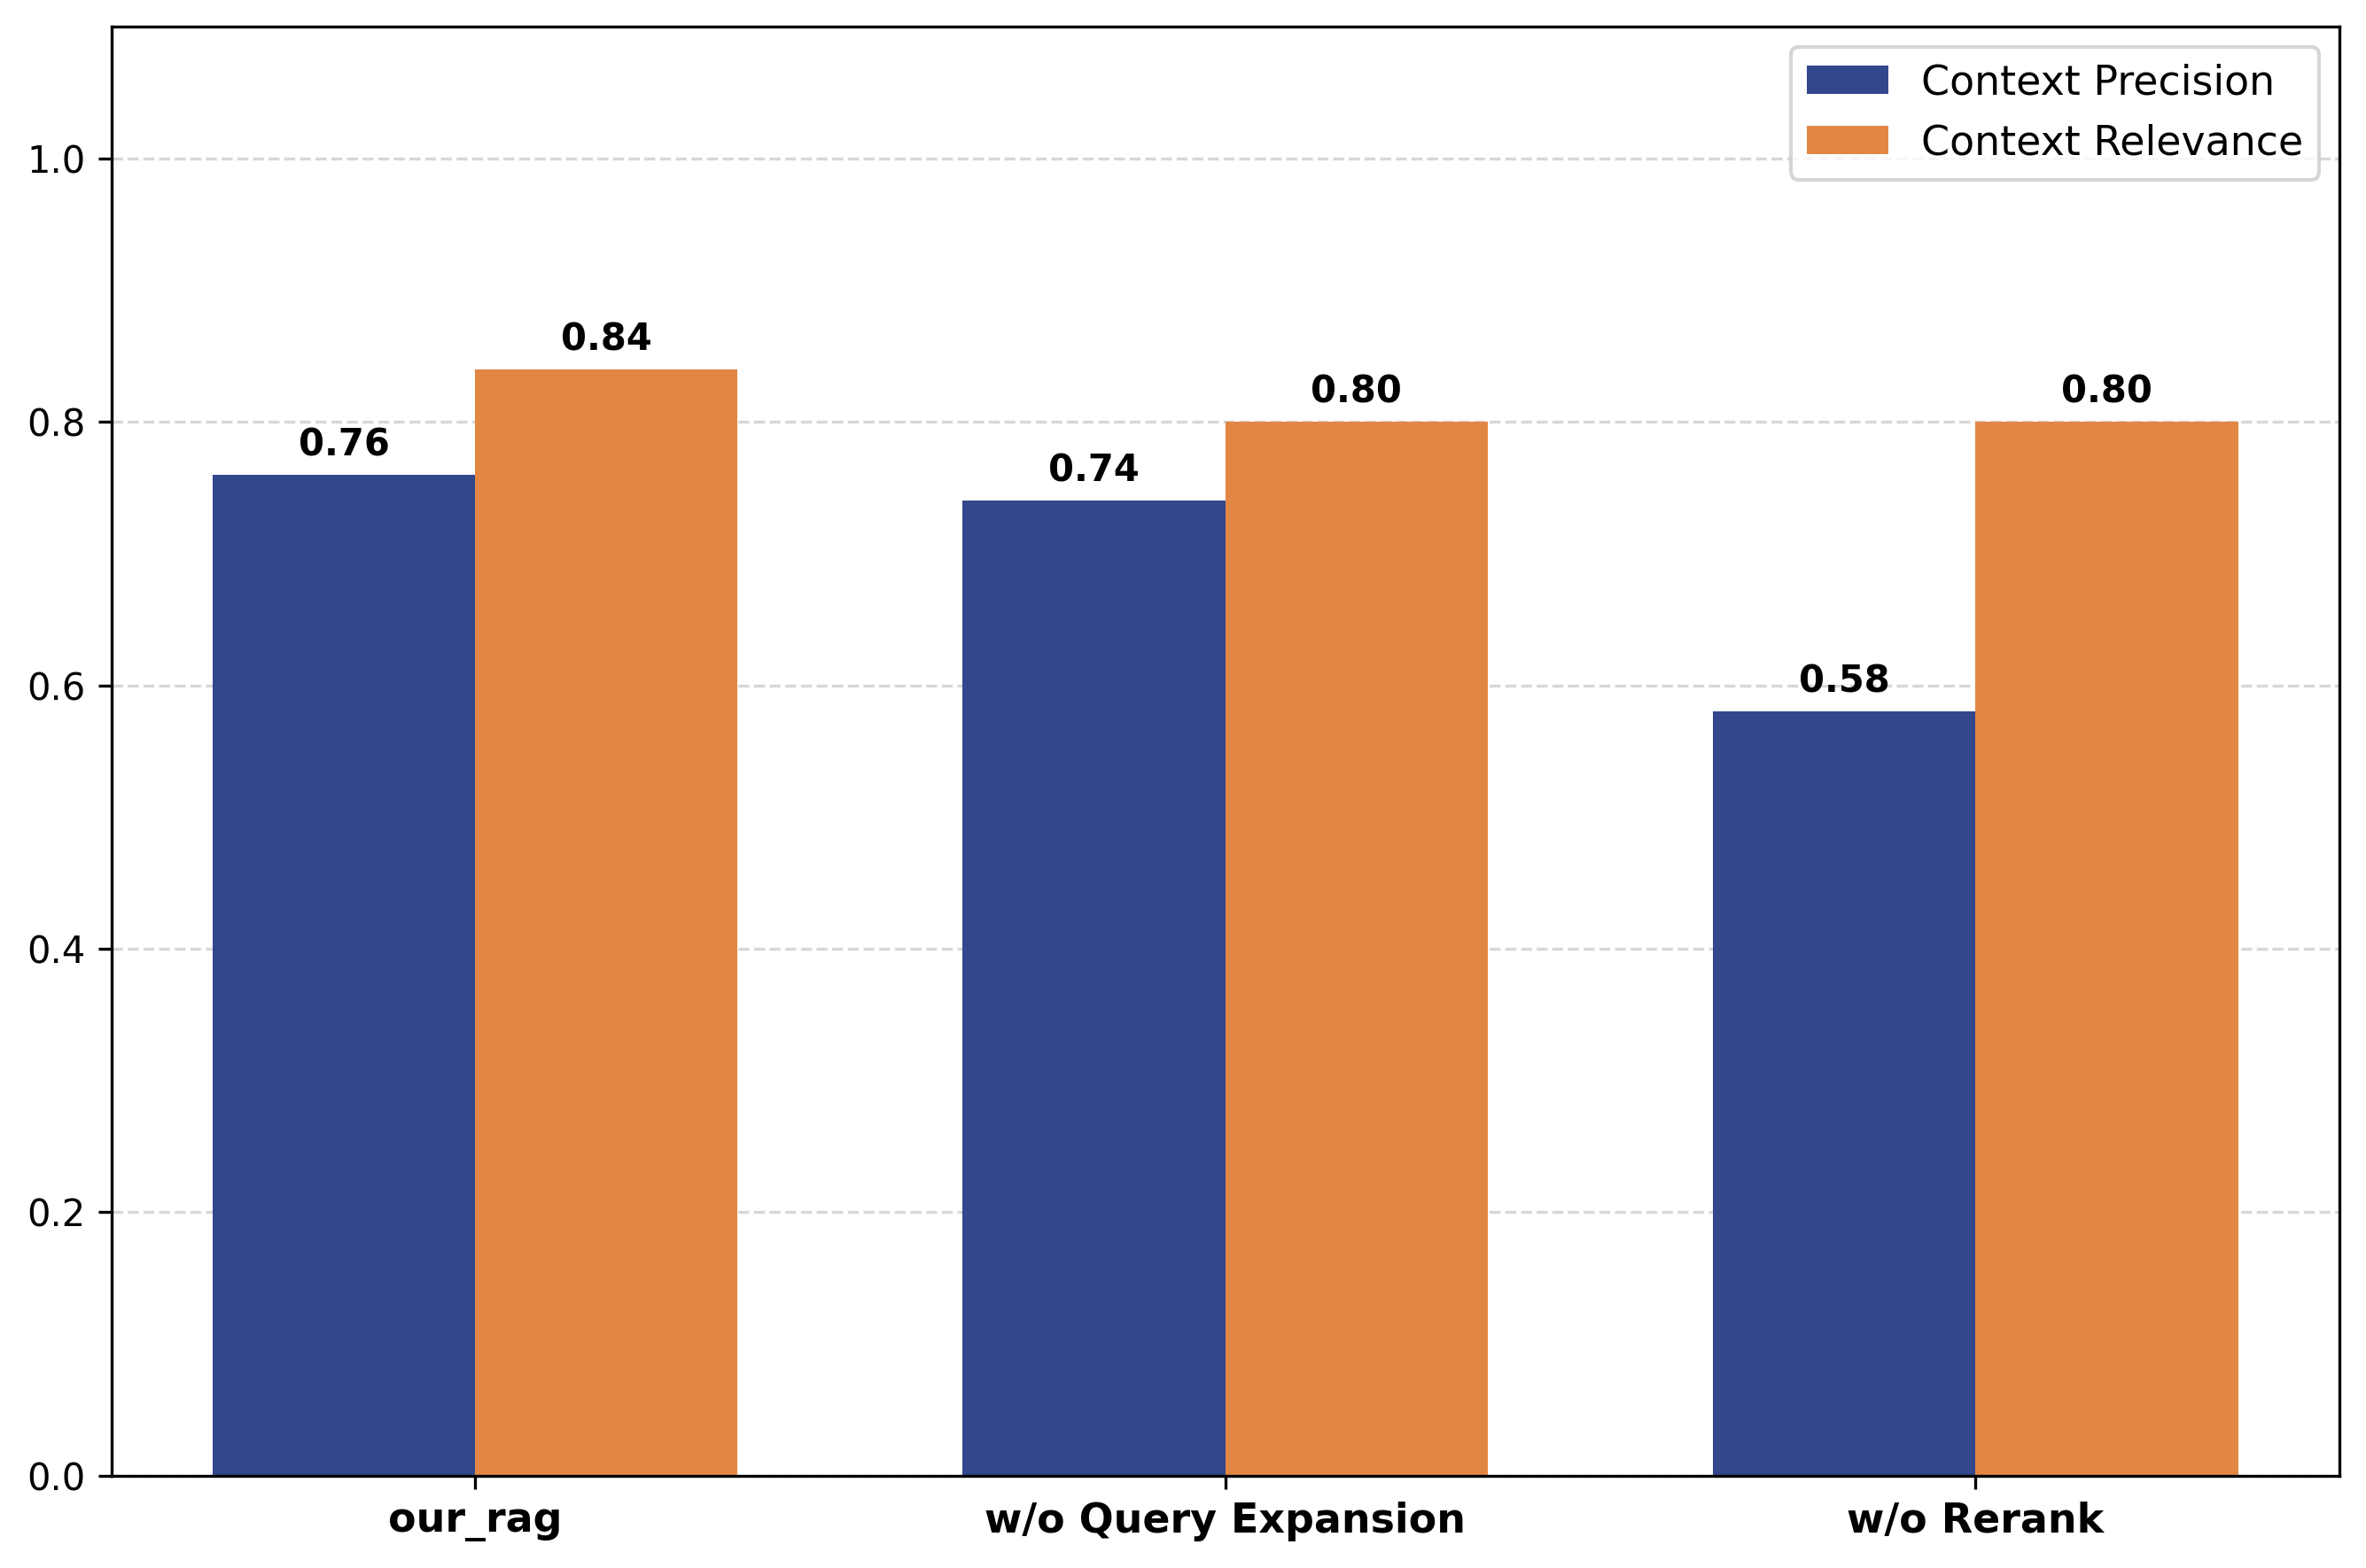

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu thô (Chưa sắp xếp)
labels_raw = ['our_rag', 'w/o Rerank', 'w/o Query Expansion']
precision_raw = [0.76, 0.58, 0.74]
relevancy_raw = [0.84, 0.80, 0.80]

# 2. Tự động sắp xếp giảm dần dựa theo điểm số của Precision
# Hàm zip() sẽ gộp các list lại, sorted(..., reverse=True) sẽ sắp xếp từ lớn đến bé
sorted_data = sorted(zip(precision_raw, relevancy_raw, labels_raw), reverse=True)

# Tách dữ liệu đã sắp xếp ngược lại thành các list riêng lẻ
precision_scores, relevancy_scores, labels = zip(*sorted_data)

# 3. Khởi tạo bản vẽ
x = np.arange(len(labels))  # Vị trí của các nhóm trên trục X
width = 0.35  # Độ rộng của mỗi cột
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# 4. Vẽ các cột (Màu chủ đạo #32478c cho cột Precision quyết định thứ tự giảm dần)
rects1 = ax.bar(x - width/2, precision_scores, width, label='Context Precision', color='#32478c')
rects2 = ax.bar(x + width/2, relevancy_scores, width, label='Context Relevance', color='#e28743')

# 5. Trang trí trục và nhãn
# ax.set_ylabel('Scores (0.0 - 1.0)', fontsize=12, fontweight='bold', labelpad=10)
# ax.set_title('Ablation Study: Retrieval Phase (Sorted by Precision)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 6. Hàm tự động hiển thị số trên đầu cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# 7. Lưu ảnh
plt.savefig('retrieval_ablation_sorted.png', dpi=300)
plt.show()

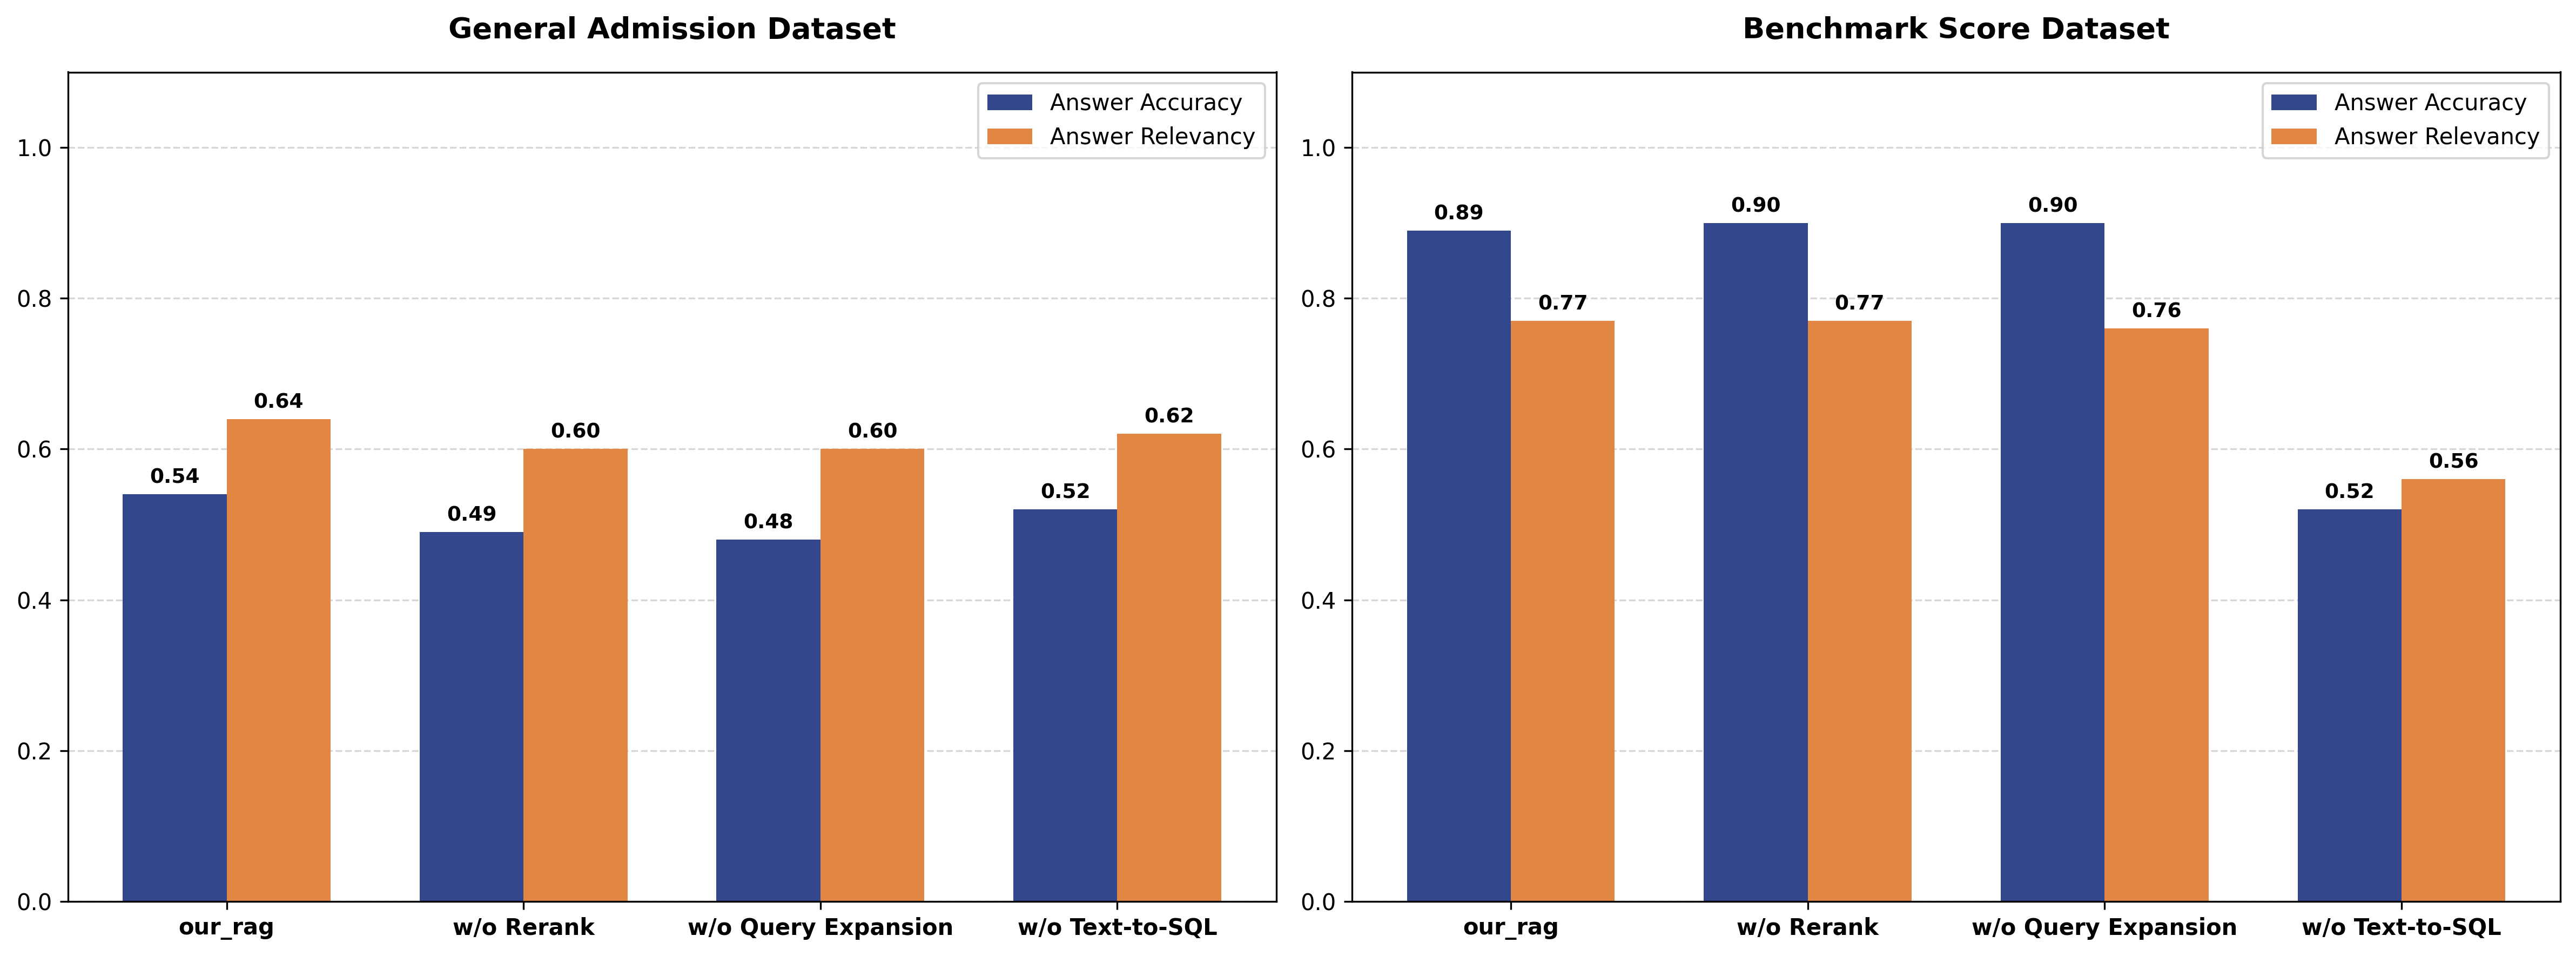

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Trục X chung cho cả 2 biểu đồ (Đã sort theo thứ tự giảm dần của cấu hình)
configs = ['our_rag', 'w/o Rerank', 'w/o Query Expansion', 'w/o Text-to-SQL']
x = np.arange(len(configs))
width = 0.35

# Dữ liệu Tập 1: Unstructured Data
unstruct_sim = [0.54, 0.49, 0.48, 0.52]  # Answer Accuracy
unstruct_rel = [0.64, 0.60, 0.60, 0.62]  # Answer Relevancy

# Dữ liệu Tập 2: Structured Data (Nơi Text-to-SQL tỏa sáng)
struct_sim = [0.89, 0.90, 0.90, 0.52]    # Tắt Text-to-SQL điểm sẽ sụt giảm nghiêm trọng
struct_rel = [0.77, 0.77, 0.76, 0.56]

# --- 2. KHỞI TẠO BẢN VẼ (1 hàng, 2 cột biểu đồ) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# --- 3. VẼ BIỂU ĐỒ 1: UNSTRUCTURED DATA (BÊN TRÁI) ---
rects1_a = ax1.bar(x - width/2, unstruct_sim, width, label='Answer Accuracy', color='#32478c')
rects1_b = ax1.bar(x + width/2, unstruct_rel, width, label='Answer Relevancy', color='#e28743')

ax1.set_title('General Admission Dataset', fontsize=13, fontweight='bold', pad=15)
# ax1.set_ylabel('Scores (0.0 - 1.0)', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(configs, fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.legend(loc='upper right')

# --- 4. VẼ BIỂU ĐỒ 2: STRUCTURED DATA (BÊN PHẢI) ---
rects2_a = ax2.bar(x - width/2, struct_sim, width, label='Answer Accuracy', color='#32478c')
rects2_b = ax2.bar(x + width/2, struct_rel, width, label='Answer Relevancy', color='#e28743')

ax2.set_title('Benchmark Score Dataset', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(configs, fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.legend(loc='upper right')

# --- 5. HÀM ĐÍNH SỐ LÊN ĐẦU CỘT ---
def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(ax1, rects1_a)
autolabel(ax1, rects1_b)
autolabel(ax2, rects2_a)
autolabel(ax2, rects2_b)

# Tổng thể tiêu đề lớn của cả slide
# plt.suptitle('Generator Phase Ablation Study across Datasets', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Lưu ảnh
plt.savefig('generator_ablation_subplots.png', dpi=300)
plt.show()